In [3]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")


# ============================================================================
# CELL 2: Define Paths
# ============================================================================
train_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/train"
val_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/val"
test_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/test"

print("="*70)
print("DATASET PATHS")
print("="*70)
print(f"Train: {train_dir}")
print(f"Val: {val_dir}")
print(f"Test: {test_dir}")
print("="*70)


# ============================================================================
# CELL 3: Count Images in Each Directory
# ============================================================================
def count_images(directory):
    """Count total images in directory"""
    total = 0
    class_counts = {}
    
    for root, dirs, files in os.walk(directory):
        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        total += len(image_files)
        
        # Count per class
        if root != directory:
            class_name = os.path.basename(root)
            class_counts[class_name] = len(image_files)
    
    return total, class_counts

train_samples, train_classes = count_images(train_dir)
val_samples, val_classes = count_images(val_dir)
test_samples, test_classes = count_images(test_dir)
total_samples = train_samples + val_samples + test_samples

print("\n" + "="*70)
print("DATASET SIZE ANALYSIS")
print("="*70)
print(f"\nTrain samples: {train_samples}")
for cls, count in train_classes.items():
    print(f"  - {cls}: {count}")

print(f"\nValidation samples: {val_samples}")
for cls, count in val_classes.items():
    print(f"  - {cls}: {count}")

print(f"\nTest samples: {test_samples}")
for cls, count in test_classes.items():
    print(f"  - {cls}: {count}")

print(f"\n{'='*70}")
print(f"TOTAL SAMPLES: {total_samples}")
print("="*70)

TensorFlow version: 2.18.0
GPU Available: True
DATASET PATHS
Train: /kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/train
Val: /kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/val
Test: /kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/test

DATASET SIZE ANALYSIS

Train samples: 34792
  - 2: 7000
  - 0: 7000
  - 3: 7000
  - 1: 6792
  - 4: 7000

Validation samples: 9940
  - 2: 2000
  - 0: 2000
  - 3: 2000
  - 1: 1940
  - 4: 2000

Test samples: 4971
  - 2: 1000
  - 0: 1000
  - 3: 1000
  - 1: 971
  - 4: 1000

TOTAL SAMPLES: 49703


In [6]:
# Decide strategy
if total_samples < 1000:
    strategy = "FREEZE_ALL"
    print("\n Strategy: FREEZE_ALL")
elif total_samples < 5000:
    strategy = "FREEZE_MOST"
    print("\n Strategy: FREEZE_MOST")
elif total_samples < 10000:
    strategy = "FINETUNE_PARTIAL"
    print("\n Strategy: FINETUNE_PARTIAL")
else:
    strategy = "FINETUNE_ALL"
    print("\n Strategy: FINETUNE_ALL")



 Strategy: FINETUNE_ALL


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
# ============================================================================
# CELL 4: Create Image Data Generators
# ============================================================================
print("\nSetting up data generators...")

# Training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data without augmentation
val_datagen = ImageDataGenerator(rescale=1./255)

# Test data without augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

print("✓ Data generators created")


# ============================================================================
# CELL 5: Load Data from Directories
# ============================================================================
print("\nLoading datasets...")

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_ds = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(f" Train dataset loaded: {train_ds.samples} samples")
print(f" Validation dataset loaded: {val_ds.samples} samples")
print(f" Test dataset loaded: {test_ds.samples} samples")
print(f" Number of classes: {train_ds.num_classes}")
print(f" Classes: {train_ds.class_indices}")




Setting up data generators...
✓ Data generators created

Loading datasets...
Found 34792 images belonging to 5 classes.
Found 9940 images belonging to 5 classes.
Found 4971 images belonging to 5 classes.
 Train dataset loaded: 34792 samples
 Validation dataset loaded: 9940 samples
 Test dataset loaded: 4971 samples
 Number of classes: 5
 Classes: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


In [4]:
# ============================================================================
# CELL 6: Define Custom Layers
# ============================================================================
class ClassToken(layers.Layer):
    """Adds learnable class token"""
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer="zeros",
            trainable=True,
            name="cls_token"
        )
    
    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        return tf.concat([cls_tokens, x], axis=1)


class PositionalEmbedding(layers.Layer):
    """Adds learnable positional embeddings"""
    def __init__(self, n_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.n_patches = n_patches
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(self.n_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True,
            name="pos_emb"
        )
    
    def call(self, x):
        return x + self.pos_emb


In [5]:
# ============================================================================
# CELL 7: Define Transformer Encoder
# ============================================================================
def transformer_encoder(inputs, num_heads=4, embed_dim=384, mlp_dim=768, dropout=0.2):
    """Transformer encoder block"""
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.Add()([x, attn_out])
    y = layers.LayerNormalization(epsilon=1e-6)(x)
    y = layers.Dense(mlp_dim, activation='gelu')(y)
    y = layers.Dropout(dropout)(y)
    y = layers.Dense(embed_dim)(y)
    y = layers.Dropout(dropout)(y)
    return layers.Add()([x, y])


In [7]:
# ============================================================================
# CELL 8: Build Hybrid Model
# ============================================================================
def build_hybrid_model(num_classes=5, embedding_dim=384, num_transformer_blocks=4):
    """Build hybrid CNN + Vision Transformer model"""
    
    inputs = layers.Input(shape=(224, 224, 3))
    
    # CNN Backbone
    base = tf.keras.applications.EfficientNetB2(
        include_top=False,
        input_tensor=inputs,
        weights='imagenet'
    )
    
    x = base.output
    
    # Project to embedding dimension
    x = layers.Conv2D(embedding_dim, kernel_size=1, padding='same')(x)
    
    # Get patch dimensions
    H, W = x.shape[1], x.shape[2]
    n_patches = H * W
    
    # Reshape to sequence
    x = layers.Reshape((n_patches, embedding_dim))(x)
    
    # Add class token and positional embeddings
    x = ClassToken(embedding_dim)(x)
    x = PositionalEmbedding(n_patches, embedding_dim)(x)
    
    # Transformer blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, num_heads=4, embed_dim=embedding_dim)
    
    # Classification head
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="hybrid_efficientnet_vit")
    return model, base



In [15]:
# ============================================================================
# CELL 9: Build and Apply Freezing Strategy
# ============================================================================
print("\n" + "="*70)
print(f"BUILDING MODEL WITH STRATEGY: {strategy}")
print("="*70)

model, base = build_hybrid_model(num_classes=train_ds.num_classes)

if strategy == "FREEZE_ALL":
    print("\n✓ STRATEGY: FREEZE_ALL")
    print("  Freezing entire backbone...")
    for layer in base.layers:
        layer.trainable = False
    learning_rate = 1e-4

elif strategy == "FREEZE_MOST":
    print("\n✓ STRATEGY: FREEZE_MOST")
    print("  Freezing first 150 layers...")
    for layer in base.layers[:150]:
        layer.trainable = False
    for layer in base.layers[150:]:
        layer.trainable = True
    learning_rate = 5e-5

elif strategy == "FINETUNE_PARTIAL":
    print("\n✓ STRATEGY: FINETUNE_PARTIAL")
    print("  Freezing first 100 layers...")
    for layer in base.layers[:100]:
        layer.trainable = False
    for layer in base.layers[100:]:
        layer.trainable = True
    learning_rate = 3e-5

else:  # FINETUNE_ALL
    print("\n✓ STRATEGY: FINETUNE_ALL")
    print("  Training all layers...")
    for layer in base.layers:
        layer.trainable = True
    learning_rate = 1e-5

# Count parameters
trainable = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
total = model.count_params()

print(f"\nTrainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")
print(f"Frozen parameters: {total-trainable:,} ({100*(total-trainable)/total:.1f}%)")
print(f"Total parameters: {total:,}")
print(f"Learning rate: {learning_rate}")




BUILDING MODEL WITH STRATEGY: FINETUNE_ALL

✓ STRATEGY: FINETUNE_ALL
  Training all layers...

Trainable parameters: 20,189,447 (99.7%)
Frozen parameters: 67,575 (0.3%)
Total parameters: 20,257,022
Learning rate: 1e-05


In [17]:
# ============================================================================
# CELL 10: Compile Model
# ============================================================================
print("\nCompiling model...")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled!")


Compiling model...
 Model compiled!


In [18]:
# ============================================================================
# CELL 11: Setup Callbacks
# ============================================================================
os.makedirs("saved_models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath="saved_models/best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, lr_reduce, early_stop]

print(" Callbacks configured!")

 Callbacks configured!


In [20]:
from datetime import datetime

# ============================================================================
# CELL 12: Train Model
# ============================================================================
print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Train batches: {len(train_ds)}")
print(f"Val batches: {len(val_ds)}")
print("="*70 + "\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)



STARTING TRAINING
Start time: 2025-12-13 06:40:25
Train batches: 1088
Val batches: 311



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1765608085.486503     188 service.cc:148] XLA service 0x7bd46c002920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765608085.487205     188 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765608085.487227     188 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765608094.034401     188 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1765608110.086039     188 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765608110.230998     188 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765608110.729876     188 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

 752/1088 ━━━━━━━━━━━━━━━━━━━━ 3:19 594ms/step - accuracy: 0.3349 - loss: 1.4639

...

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 484s 445ms/step - accuracy: 0.6601 - loss: 0.7974 - val_accuracy: 0.6771 - val_loss: 0.7605 - learning_rate: 6.2500e-07
Epoch 32/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.6638 - loss: 0.8009
Epoch 32: val_accuracy did not improve from 0.67706
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 490s 451ms/step - accuracy: 0.6638 - loss: 0.8009 - val_accuracy: 0.6754 - val_loss: 0.7611 - learning_rate: 6.2500e-07
Epoch 33/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.6578 - loss: 0.7992
Epoch 33: val_accuracy did not improve from 0.67706
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 486s 446ms/step - accuracy: 0.6578 - loss: 0.7992 - val_accuracy: 0.6731 - val_loss: 0.7701 - learning_rate: 6.2500e-07
Epoch 34/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.6610 - loss: 0.7958
Epoch 34: val_accuracy improved from 0.67706 to 0.67867, saving model to saved_models/best_model.h5


1088/1088 ━━━━━━━━━━━━━━━━━━━━ 494s 454ms/step - accuracy: 0.6610 - loss: 0.7958 - val_accuracy: 0.6787 - val_loss: 0.7598 - learning_rate: 6.2500e-07
Epoch 35/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.6611 - loss: 0.7945
Epoch 35: val_accuracy did not improve from 0.67867
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 494s 454ms/step - accuracy: 0.6611 - loss: 0.7945 - val_accuracy: 0.6763 - val_loss: 0.7745 - learning_rate: 6.2500e-07
Epoch 36/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.6609 - loss: 0.7942
Epoch 36: val_accuracy did not improve from 0.67867
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 488s 448ms/step - accuracy: 0.6610 - loss: 0.7942 - val_accuracy: 0.6746 - val_loss: 0.7631 - learning_rate: 6.2500e-07
Epoch 37/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.6645 - loss: 0.7894
Epoch 37: val_accuracy did not improve from 0.67867

Epoch 37: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-07.
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 487s 447ms

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 490s 451ms/step - accuracy: 0.6631 - loss: 0.7879 - val_accuracy: 0.6802 - val_loss: 0.7541 - learning_rate: 3.1250e-07
Epoch 40/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.6648 - loss: 0.7936
Epoch 40: val_accuracy did not improve from 0.68018
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 491s 451ms/step - accuracy: 0.6648 - loss: 0.7936 - val_accuracy: 0.6793 - val_loss: 0.7528 - learning_rate: 3.1250e-07
Epoch 41/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.6623 - loss: 0.7901
Epoch 41: val_accuracy did not improve from 0.68018
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 485s 446ms/step - accuracy: 0.6623 - loss: 0.7901 - val_accuracy: 0.6800 - val_loss: 0.7506 - learning_rate: 3.1250e-07
Epoch 42/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.6691 - loss: 0.7781
Epoch 42: val_accuracy did not improve from 0.68018
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 485s 446ms/step - accuracy: 0.6691 - loss: 0.7781 - val_accuracy: 0.6798 - val_loss: 0.

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 519s 477ms/step - accuracy: 0.6620 - loss: 0.7899 - val_accuracy: 0.6835 - val_loss: 0.7456 - learning_rate: 3.1250e-07
Epoch 45/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.6689 - loss: 0.7823
Epoch 45: val_accuracy did not improve from 0.68350
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 511s 469ms/step - accuracy: 0.6689 - loss: 0.7823 - val_accuracy: 0.6821 - val_loss: 0.7456 - learning_rate: 3.1250e-07
Epoch 46/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.6655 - loss: 0.7840
Epoch 46: val_accuracy did not improve from 0.68350
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 499s 459ms/step - accuracy: 0.6655 - loss: 0.7840 - val_accuracy: 0.6769 - val_loss: 0.7561 - learning_rate: 3.1250e-07
Epoch 47/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.6649 - loss: 0.7810
Epoch 47: val_accuracy did not improve from 0.68350

Epoch 47: ReduceLROnPlateau reducing learning rate to 1.56249996052793e-07.
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 500s 459ms

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 495s 455ms/step - accuracy: 0.6679 - loss: 0.7850 - val_accuracy: 0.6840 - val_loss: 0.7410 - learning_rate: 1.5625e-07
Epoch 50/50
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.6638 - loss: 0.7832
Epoch 50: val_accuracy did not improve from 0.68400
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 494s 453ms/step - accuracy: 0.6638 - loss: 0.7832 - val_accuracy: 0.6803 - val_loss: 0.7510 - learning_rate: 1.5625e-07
Restoring model weights from the end of the best epoch: 49.

TRAINING COMPLETED!


### Fine tuning stage 1


In [31]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import os

print("="*70)
print("FINE-TUNING DIABETIC RETINOPATHY MODEL")
print("="*70)

FINE-TUNING DIABETIC RETINOPATHY MODEL


In [32]:
# ============================================================================
# CELL 1: Define Custom Layers
# ============================================================================
class ClassToken(layers.Layer):
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim), 
            initializer="zeros", 
            trainable=True, 
            name="cls_token"
        )
    
    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        return tf.concat([cls_tokens, x], axis=1)
    
    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim})
        return config


class PositionalEmbedding(layers.Layer):
    def __init__(self, n_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.n_patches = n_patches
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(self.n_patches + 1, self.embed_dim), 
            initializer="random_normal", 
            trainable=True, 
            name="pos_emb"
        )
    
    def call(self, x):
        return x + self.pos_emb
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "n_patches": self.n_patches,
            "embed_dim": self.embed_dim
        })
        return config


print("✓ Custom layers defined")


✓ Custom layers defined


In [33]:
# ============================================================================
# CELL 2: Load Model
# ============================================================================
print("\n" + "="*70)
print("LOADING MODEL")
print("="*70)

model_path = "/kaggle/input/1ststage-model1/keras/default/1/best_model.h5"

try:
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            'ClassToken': ClassToken,
            'PositionalEmbedding': PositionalEmbedding
        }
    )
    print(f"✓ Model loaded successfully!")
    print(f"✓ Parameters: {model.count_params():,}")
except Exception as e:
    print(f"✗ Error: {e}")
    raise




LOADING MODEL


✓ Model loaded successfully!
✓ Parameters: 20,257,022


In [35]:
#============================================================================
# CELL 3: Load Datasets
# ============================================================================
print("\n" + "="*70)
print("LOADING DATASETS")
print("="*70)

train_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/train"
val_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/val"
test_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/test"

# Aggressive augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_ds = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=True
)
val_ds = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)
test_ds = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)

print(f"✓ Train: {train_ds.samples} | Val: {val_ds.samples} | Test: {test_ds.samples}")



LOADING DATASETS
Found 34792 images belonging to 5 classes.
Found 9940 images belonging to 5 classes.
Found 4971 images belonging to 5 classes.
✓ Train: 34792 | Val: 9940 | Test: 4971


In [36]:
print("\n" + "="*70)
print("SMART LAYER FREEZING STRATEGY")
print("="*70)


frozen_count = 0
trainable_count = 0

for i, layer in enumerate(model.layers):

    if i < 100:
        layer.trainable = False
        frozen_count += 1
    else:
        layer.trainable = True
        trainable_count += 1

total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
frozen_params = total_params - trainable_params

print(f"\n✓ FREEZING STRATEGY:")
print(f"  Frozen layers: {frozen_count} (low-level features)")
print(f"  Trainable layers: {trainable_count} (high-level features)")
print(f"  Frozen params: {frozen_params:,} ({100*frozen_params/total_params:.1f}%)")
print(f"  Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")



SMART LAYER FREEZING STRATEGY

✓ FREEZING STRATEGY:
  Frozen layers: 100 (low-level features)
  Trainable layers: 290 (high-level features)
  Frozen params: 157,717 (0.8%)
  Trainable params: 20,099,305 (99.2%)


In [37]:
print("\n" + "="*70)
print("COMPILING MODEL")
print("="*70)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model compiled with learning rate: 3e-5")



COMPILING MODEL
✓ Model compiled with learning rate: 3e-5


In [38]:
print("\n" + "="*70)
print("STARTING TRAINING - 30 EPOCHS")
print("="*70 + "\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    verbose=1
)

print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)


STARTING TRAINING - 30 EPOCHS

Epoch 1/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 688s 545ms/step - accuracy: 0.6102 - loss: 0.9229 - val_accuracy: 0.6673 - val_loss: 0.7642
Epoch 2/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 533s 489ms/step - accuracy: 0.6183 - loss: 0.8978 - val_accuracy: 0.6804 - val_loss: 0.7370
Epoch 3/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 535s 491ms/step - accuracy: 0.6376 - loss: 0.8649 - val_accuracy: 0.6982 - val_loss: 0.7102
Epoch 4/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 531s 488ms/step - accuracy: 0.6451 - loss: 0.8379 - val_accuracy: 0.6921 - val_loss: 0.7105
Epoch 5/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 522s 480ms/step - accuracy: 0.6518 - loss: 0.8140 - val_accuracy: 0.6996 - val_loss: 0.6932
Epoch 6/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 517s 475ms/step - accuracy: 0.6609 - loss: 0.7876 - val_accuracy: 0.7045 - val_loss: 0.6899
Epoch 7/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 521s 478ms/step - accuracy: 0.6748 - loss: 0.7646 - val_accuracy: 0.7153 - val_loss: 0.6660
Epoch 8/30
1088/1088 ━━━━━━━━━

In [39]:
print("\nEvaluating on test set...")
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\n✓ Test Accuracy: {test_accuracy:.4f}")
print(f"✓ Test Loss: {test_loss:.4f}")


Evaluating on test set...
156/156 ━━━━━━━━━━━━━━━━━━━━ 44s 283ms/step - accuracy: 0.7468 - loss: 0.6581

✓ Test Accuracy: 0.7924
✓ Test Loss: 0.5175


In [41]:
print("\nSaving model...")
os.makedirs("final_models", exist_ok=True)


model.save("final_models/finetuned_model.keras")
print("✓ Saved as: final_models/finetuned_model.keras")





Saving model...
✓ Saved as: final_models/finetuned_model.keras


### 2nd stage

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping,LearningRateScheduler
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
print("="*70)
print("2ND STAGE FINE-TUNING - AGGRESSIVE STRATEGY")
print("="*70)
print("\nPrevious Results:")
print("  Test Accuracy: 79.24%")
print("  Test Loss: 0.5175")
print("\nTarget: 82-85%+")

2ND STAGE FINE-TUNING - AGGRESSIVE STRATEGY

Previous Results:
  Test Accuracy: 79.24%
  Test Loss: 0.5175

Target: 82-85%+


In [5]:
class ClassToken(layers.Layer):
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim), 
            initializer="zeros", 
            trainable=True, 
            name="cls_token"
        )
    
    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        return tf.concat([cls_tokens, x], axis=1)
    
    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim})
        return config


class PositionalEmbedding(layers.Layer):
    def __init__(self, n_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.n_patches = n_patches
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(self.n_patches + 1, self.embed_dim), 
            initializer="random_normal", 
            trainable=True, 
            name="pos_emb"
        )
    
    def call(self, x):
        return x + self.pos_emb
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "n_patches": self.n_patches,
            "embed_dim": self.embed_dim
        })
        return config


print(" Custom layers defined")


 Custom layers defined


In [6]:
print("\n" + "="*70)
print("LOADING STAGE 1 MODEL")
print("="*70)

model_path = "/kaggle/input/2nd-model-finetuned1/keras/default/1/finetuned_model.keras"

try:
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            'ClassToken': ClassToken,
            'PositionalEmbedding': PositionalEmbedding
        }
    )
    print(f"✓ Model loaded successfully!")
    print(f"✓ Path: {model_path}")
    print(f"✓ Parameters: {model.count_params():,}")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    raise



LOADING STAGE 1 MODEL


I0000 00:00:1766414636.311213      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766414636.311828      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✓ Model loaded successfully!
✓ Path: /kaggle/input/2nd-model-finetuned1/keras/default/1/finetuned_model.keras
✓ Parameters: 20,257,022


In [7]:
print("\n" + "="*70)
print("LOADING DATASETS")
print("="*70)

train_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/train"
val_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/val"
test_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/test"

# BALANCED augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 24  # Optimized

train_ds = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=batch_size, 
    class_mode='categorical', shuffle=True, seed=42
)

val_ds = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=batch_size, 
    class_mode='categorical', shuffle=False
)

test_ds = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=batch_size, 
    class_mode='categorical', shuffle=False
)

print(f"✓ Train: {train_ds.samples} | Val: {val_ds.samples} | Test: {test_ds.samples}")




LOADING DATASETS
Found 34792 images belonging to 5 classes.
Found 9940 images belonging to 5 classes.
Found 4971 images belonging to 5 classes.
✓ Train: 34792 | Val: 9940 | Test: 4971


In [8]:
print("\n" + "="*70)
print("PROGRESSIVE LAYER UNFREEZING")
print("="*70)

frozen_count = 0
trainable_count = 0

for i, layer in enumerate(model.layers):
    if i < 80:  # Freeze first 80
        layer.trainable = False
        frozen_count += 1
    else:
        layer.trainable = True
        trainable_count += 1

total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
frozen_params = total_params - trainable_params

print(f"\n✓ Layer Configuration:")
print(f"  Frozen layers: {frozen_count}")
print(f"  Trainable layers: {trainable_count}")
print(f"  Frozen params: {frozen_params:,} ({100*frozen_params/total_params:.1f}%)")
print(f"  Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")



PROGRESSIVE LAYER UNFREEZING

✓ Layer Configuration:
  Frozen layers: 80
  Trainable layers: 310
  Frozen params: 105,619 (0.5%)
  Trainable params: 20,151,403 (99.5%)


In [9]:
print("\n" + "="*70)
print("COMPILING MODEL")
print("="*70)

# Lower learning rate برائے fine-tuning
learning_rate = 1e-5

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✓ Compiled with:")
print(f"  Optimizer: Adam")
print(f"  Learning Rate: {learning_rate}")
print(f"  Loss: Categorical Crossentropy")




COMPILING MODEL
✓ Compiled with:
  Optimizer: Adam
  Learning Rate: 1e-05
  Loss: Categorical Crossentropy


In [10]:
print("\n" + "="*70)
print("SETTING UP CALLBACKS")
print("="*70)

os.makedirs("final_models", exist_ok=True)

# Learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch > 0 and epoch % 5 == 0:
        new_lr = lr * 0.9
        print(f"\n  Learning rate reduced to {new_lr}")
        return new_lr
    return lr

lr_schedule = LearningRateScheduler(lr_scheduler, verbose=0)

# Model checkpoint
checkpoint = ModelCheckpoint(
    "final_models/best_continued_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# Learning rate reduction
lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.8,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Early stopping
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True,
    verbose=1,
    mode="max"
)

callbacks = [checkpoint, lr_schedule, lr_reduce, early_stop]

print("✓ Callbacks ready:")
print("  1. ModelCheckpoint")
print("  2. LearningRateScheduler")
print("  3. ReduceLROnPlateau")
print("  4. EarlyStopping")



SETTING UP CALLBACKS
✓ Callbacks ready:
  1. ModelCheckpoint
  2. LearningRateScheduler
  3. ReduceLROnPlateau
  4. EarlyStopping


In [12]:
from datetime import datetime
print("\n" + "="*70)
print("TRAINING - STAGE 2 CONTINUATION")
print("="*70)
print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,  # More epochs for better convergence
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)



TRAINING - STAGE 2 CONTINUATION
Start: 2025-12-22 14:47:01



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1766414872.676160     114 service.cc:148] XLA service 0x7d0f6c107e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766414872.677761     114 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766414872.677799     114 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766414880.216187     114 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1766414893.212823     114 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766414893.354941     114 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766414893.825355     114 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

 720/1450 ━━━━━━━━━━━━━━━━━━━━ 6:25 528ms/step - accuracy: 0.8284 - loss: 0.4167

E0000 00:00:1766415324.691446     112 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766415324.832072     112 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766415325.180011     112 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766415325.327917     112 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766415325.475549     112 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.8281 - loss: 0.4141
Epoch 1: val_accuracy improved from -inf to 0.80091, saving model to final_models/best_continued_model.keras
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 1053s 653ms/step - accuracy: 0.8281 - loss: 0.4141 - val_accuracy: 0.8009 - val_loss: 0.4825 - learning_rate: 1.0000e-05
Epoch 2/20
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8367 - loss: 0.3899
Epoch 2: val_accuracy improved from 0.80091 to 0.80262, saving model to final_models/best_continued_model.keras
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 582s 401ms/step - accuracy: 0.8367 - loss: 0.3899 - val_accuracy: 0.8026 - val_loss: 0.4936 - learning_rate: 1.0000e-05
Epoch 3/20
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.8385 - loss: 0.3871
Epoch 3: val_accuracy improved from 0.80262 to 0.80815, saving model to final_models/best_continued_model.keras
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 594s 410ms/step - accuracy: 0.8385 - loss: 0.3871 - val_accuracy: 0.8081 -


Creating plots...


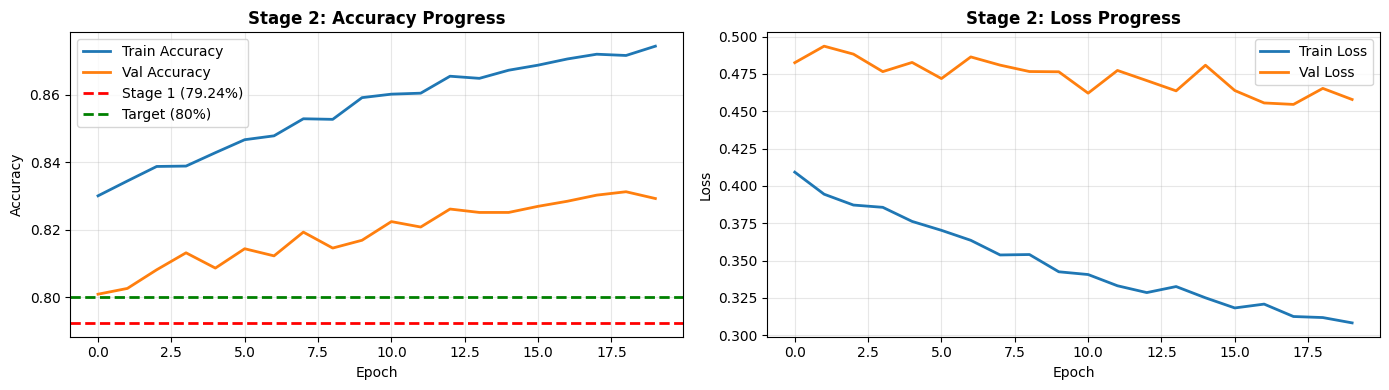

✓ Plot saved: final_models/stage2_continued_history.png


In [13]:
print("\nCreating plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].axhline(y=0.7924, color='red', linestyle='--', label='Stage 1 (79.24%)', linewidth=2)
axes[0].axhline(y=0.80, color='green', linestyle='--', label='Target (80%)', linewidth=2)
axes[0].set_title('Stage 2: Accuracy Progress', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Stage 2: Loss Progress', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("final_models/stage2_continued_history.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: final_models/stage2_continued_history.png")


In [15]:
print("\nEvaluating on test set...")
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\n{'='*70}")
print("RESULTS")
print(f"{'='*70}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")



Evaluating on test set...
208/208 ━━━━━━━━━━━━━━━━━━━━ 66s 320ms/step - accuracy: 0.7766 - loss: 0.6473

RESULTS
Test Accuracy: 83.12%
Test Loss: 0.4882


In [16]:
best_val_acc = max(history.history['val_accuracy'])
best_epoch = np.argmax(history.history['val_accuracy']) + 1

print(f"\n{'='*70}")
print("STAGE 1 vs STAGE 2 COMPARISON")
print(f"{'='*70}")
print(f"\nStage 1: 79.24%")
print(f"Stage 2: {test_accuracy*100:.2f}%")
print(f"Best Val Acc (Stage 2): {best_val_acc*100:.2f}%")
print(f"Best Epoch: {best_epoch}/35")

improvement = (test_accuracy - 0.7924) * 100
print(f"\n✓ Improvement: {improvement:+.2f}%")

if test_accuracy >= 0.80:
    print(f"✓✓✓ TARGET ACHIEVED (80%+)!")
else:
    print(f"Close to target - {(0.80 - test_accuracy)*100:.2f}% more needed")


STAGE 1 vs STAGE 2 COMPARISON

Stage 1: 79.24%
Stage 2: 83.12%
Best Val Acc (Stage 2): 83.13%
Best Epoch: 19/35

✓ Improvement: +3.88%
✓✓✓ TARGET ACHIEVED (80%+)!


## Testing

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_curve, auc, roc_auc_score)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# ============================================================================
# CELL 0: Define DR Stage Labels
# ============================================================================

# Diabetic Retinopathy stages
DR_STAGES = {
    0: 'No DR (Normal)',
    1: 'Mild DR',
    2: 'Moderate DR',
    3: 'Severe DR',
    4: 'Proliferative DR'
}

print("✓ DR Stages defined:")
for idx, stage in DR_STAGES.items():
    print(f"  Class {idx}: {stage}")



✓ DR Stages defined:
  Class 0: No DR (Normal)
  Class 1: Mild DR
  Class 2: Moderate DR
  Class 3: Severe DR
  Class 4: Proliferative DR


In [4]:
# ============================================================================
# CELL 1: Define Custom Layers
# ============================================================================
class ClassToken(layers.Layer):
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim), 
            initializer="zeros", 
            trainable=True, 
            name="cls_token"
        )
    
    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        return tf.concat([cls_tokens, x], axis=1)
    
    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim})
        return config


class PositionalEmbedding(layers.Layer):
    def __init__(self, n_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.n_patches = n_patches
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(self.n_patches + 1, self.embed_dim), 
            initializer="random_normal", 
            trainable=True, 
            name="pos_emb"
        )
    
    def call(self, x):
        return x + self.pos_emb
    
    def get_config(self):
        config = super().get_config()
        config.update({"n_patches": self.n_patches, "embed_dim": self.embed_dim})
        return config


print("✓ Custom layers defined")

✓ Custom layers defined


In [5]:
# ============================================================================
# CELL 2: Load Model
# ============================================================================
print("\n" + "="*70)
print("LOADING MODEL")
print("="*70)

model_path = "/kaggle/input/model3-finetuned2/keras/default/1/best_continued_model.keras"

try:
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            'ClassToken': ClassToken,
            'PositionalEmbedding': PositionalEmbedding
        }
    )
    print(f"✓ Model loaded successfully!")
    print(f"✓ Path: {model_path}")
    print(f"✓ Parameters: {model.count_params():,}")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    raise


LOADING MODEL


I0000 00:00:1766492233.149382      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766492233.150155      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✓ Model loaded successfully!
✓ Path: /kaggle/input/model3-finetuned2/keras/default/1/best_continued_model.keras
✓ Parameters: 20,257,022


In [6]:
print("\n" + "="*70)
print("LOADING TEST IMAGES")
print("="*70)

test_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/test"

# Collect all image paths from all classes
all_image_paths = []
class_mapping = {}

# Get all subdirectories (class folders: 0, 1, 2, 3, 4)
for class_folder in sorted(os.listdir(test_dir)):
    class_path = os.path.join(test_dir, class_folder)
    
    # Check if it's a directory
    if os.path.isdir(class_path):
        try:
            class_idx = int(class_folder)  # Convert folder name to integer
            class_mapping[class_idx] = class_folder
            
            # Get all images from this class folder
            for image_file in os.listdir(class_path):
                if image_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_path = os.path.join(class_path, image_file)
                    all_image_paths.append((image_path, class_idx))
            
            print(f"  Class {class_idx}: {len([p for p, c in all_image_paths if c == class_idx])} images")
        except ValueError:
            print(f"  Skipped non-numeric folder: {class_folder}")

print(f"\n✓ Total images found: {len(all_image_paths)}")
print(f"✓ Class folders: {sorted(class_mapping.keys())}")



LOADING TEST IMAGES
  Class 0: 1000 images
  Class 1: 971 images
  Class 2: 1000 images
  Class 3: 1000 images
  Class 4: 1000 images

✓ Total images found: 4971
✓ Class folders: [0, 1, 2, 3, 4]


In [7]:
print("\n" + "="*70)
print("USING FULL TEST DATASET")
print("="*70)

random_images = all_image_paths   # USE ALL TEST IMAGES

print(f"✓ Selected {len(random_images)} images (FULL TEST SET)")
print(f"✓ Class distribution:")

class_dist = {}
for _, class_idx in random_images:
    if class_idx not in class_dist:
        class_dist[class_idx] = 0
    class_dist[class_idx] += 1

for idx in sorted(class_dist.keys()):
    print(f"    {DR_STAGES[idx]:25s}: {class_dist[idx]} images")



USING FULL TEST DATASET
✓ Selected 4971 images (FULL TEST SET)
✓ Class distribution:
    No DR (Normal)           : 1000 images
    Mild DR                  : 971 images
    Moderate DR              : 1000 images
    Severe DR                : 1000 images
    Proliferative DR         : 1000 images


In [8]:
# ============================================================================
# CELL 5: Load and Preprocess Images (FULL TEST SET)
# ============================================================================
from PIL import Image
import numpy as np
import os

print("\n" + "="*70)
print("LOADING AND PREPROCESSING IMAGES")
print("="*70)

loaded_images = []
true_classes = []
image_names = []

for i, (image_path, true_class) in enumerate(random_images):
    try:
        img = Image.open(image_path).convert("RGB")
        img = img.resize((224, 224))
        img_array = np.asarray(img, dtype=np.float32) / 255.0

        loaded_images.append(img_array)
        true_classes.append(true_class)
        image_names.append(os.path.basename(image_path))

        # Print progress every 200 images (NOT every image)
        if (i + 1) % 200 == 0 or (i + 1) == len(random_images):
            print(f"  ✓ Loaded {i+1}/{len(random_images)} images")

    except Exception as e:
        print(f"  ✗ Skipped corrupted image: {image_path}")

print(f"\n✓ Successfully loaded {len(loaded_images)} images")

# Convert to NumPy arrays
if len(loaded_images) == 0:
    raise RuntimeError("No images were loaded. Check dataset paths.")

images_array = np.stack(loaded_images, axis=0)
true_classes_array = np.array(true_classes, dtype=np.int32)



LOADING AND PREPROCESSING IMAGES
  ✓ Loaded 200/4971 images
  ✓ Loaded 400/4971 images
  ✓ Loaded 600/4971 images
  ✓ Loaded 800/4971 images
  ✓ Loaded 1000/4971 images
  ✓ Loaded 1200/4971 images
  ✓ Loaded 1400/4971 images
  ✓ Loaded 1600/4971 images
  ✓ Loaded 1800/4971 images
  ✓ Loaded 2000/4971 images
  ✓ Loaded 2200/4971 images
  ✓ Loaded 2400/4971 images
  ✓ Loaded 2600/4971 images
  ✓ Loaded 2800/4971 images
  ✓ Loaded 3000/4971 images
  ✓ Loaded 3200/4971 images
  ✓ Loaded 3400/4971 images
  ✓ Loaded 3600/4971 images
  ✓ Loaded 3800/4971 images
  ✓ Loaded 4000/4971 images
  ✓ Loaded 4200/4971 images
  ✓ Loaded 4400/4971 images
  ✓ Loaded 4600/4971 images
  ✓ Loaded 4800/4971 images
  ✓ Loaded 4971/4971 images

✓ Successfully loaded 4971 images


In [9]:
print("\n" + "="*70)
print("MAKING PREDICTIONS")
print("="*70)

print("Predicting on full test dataset...")

# Use batch prediction to avoid memory issues
predictions = model.predict(
    images_array,
    batch_size=32,      # safe batch size for Kaggle
    verbose=1
)

predicted_classes = np.argmax(predictions, axis=1)
confidences = np.max(predictions, axis=1)

print(f"\n✓ Predictions generated for {len(predictions)} images")



MAKING PREDICTIONS
Predicting on full test dataset...


I0000 00:00:1766492340.450469     115 service.cc:148] XLA service 0x7f26cc003880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766492340.451372     115 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766492340.451391     115 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766492341.538554     115 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/156 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step 

I0000 00:00:1766492349.983929     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


156/156 ━━━━━━━━━━━━━━━━━━━━ 33s 129ms/step

✓ Predictions generated for 4971 images


In [10]:
print("\n" + "="*70)
print("PREDICTION RESULTS (SUMMARY)")
print("="*70)

correct_count = 0

for i in range(len(predictions)):
    if true_classes_array[i] == predicted_classes[i]:
        correct_count += 1

accuracy = correct_count / len(predictions) * 100

# Print header (only for sample display)
print(f"\n{'Image':30s} | {'True Class':25s} | {'Predicted':25s} | {'Confidence':12s} | {'Status'}")
print("-"*120)

# Show ONLY first 20 predictions as sample
sample_size = min(20, len(predictions))

for i in range(sample_size):
    true_stage = DR_STAGES[true_classes_array[i]]
    pred_stage = DR_STAGES[predicted_classes[i]]
    confidence = confidences[i]
    is_correct = "✓" if true_classes_array[i] == predicted_classes[i] else "✗"

    print(
        f"{image_names[i][:29]:30s} | "
        f"{true_stage:25s} | "
        f"{pred_stage:25s} | "
        f"{confidence:11.2%} | "
        f"{is_correct}"
    )

print("-"*120)
print(f"\n✓ Correct Predictions: {correct_count}/{len(predictions)}")
print(f"✓ Accuracy on FULL TEST DATASET: {accuracy:.2f}%")



PREDICTION RESULTS (SUMMARY)

Image                          | True Class                | Predicted                 | Confidence   | Status
------------------------------------------------------------------------------------------------------------------------
41072_left.jpeg                | No DR (Normal)            | No DR (Normal)            |      95.32% | ✓
2273_left.jpeg                 | No DR (Normal)            | No DR (Normal)            |      93.53% | ✓
43887_right.jpeg               | No DR (Normal)            | No DR (Normal)            |      97.72% | ✓
6071_left._aug_20.jpeg         | No DR (Normal)            | No DR (Normal)            |      64.21% | ✓
20252_left.jpeg                | No DR (Normal)            | No DR (Normal)            |      96.46% | ✓
36723_left.jpeg                | No DR (Normal)            | No DR (Normal)            |      99.34% | ✓
12182_left.jpeg                | No DR (Normal)            | No DR (Normal)            |      89.50% | ✓
11


CREATING VISUALIZATION (SAMPLE ONLY)


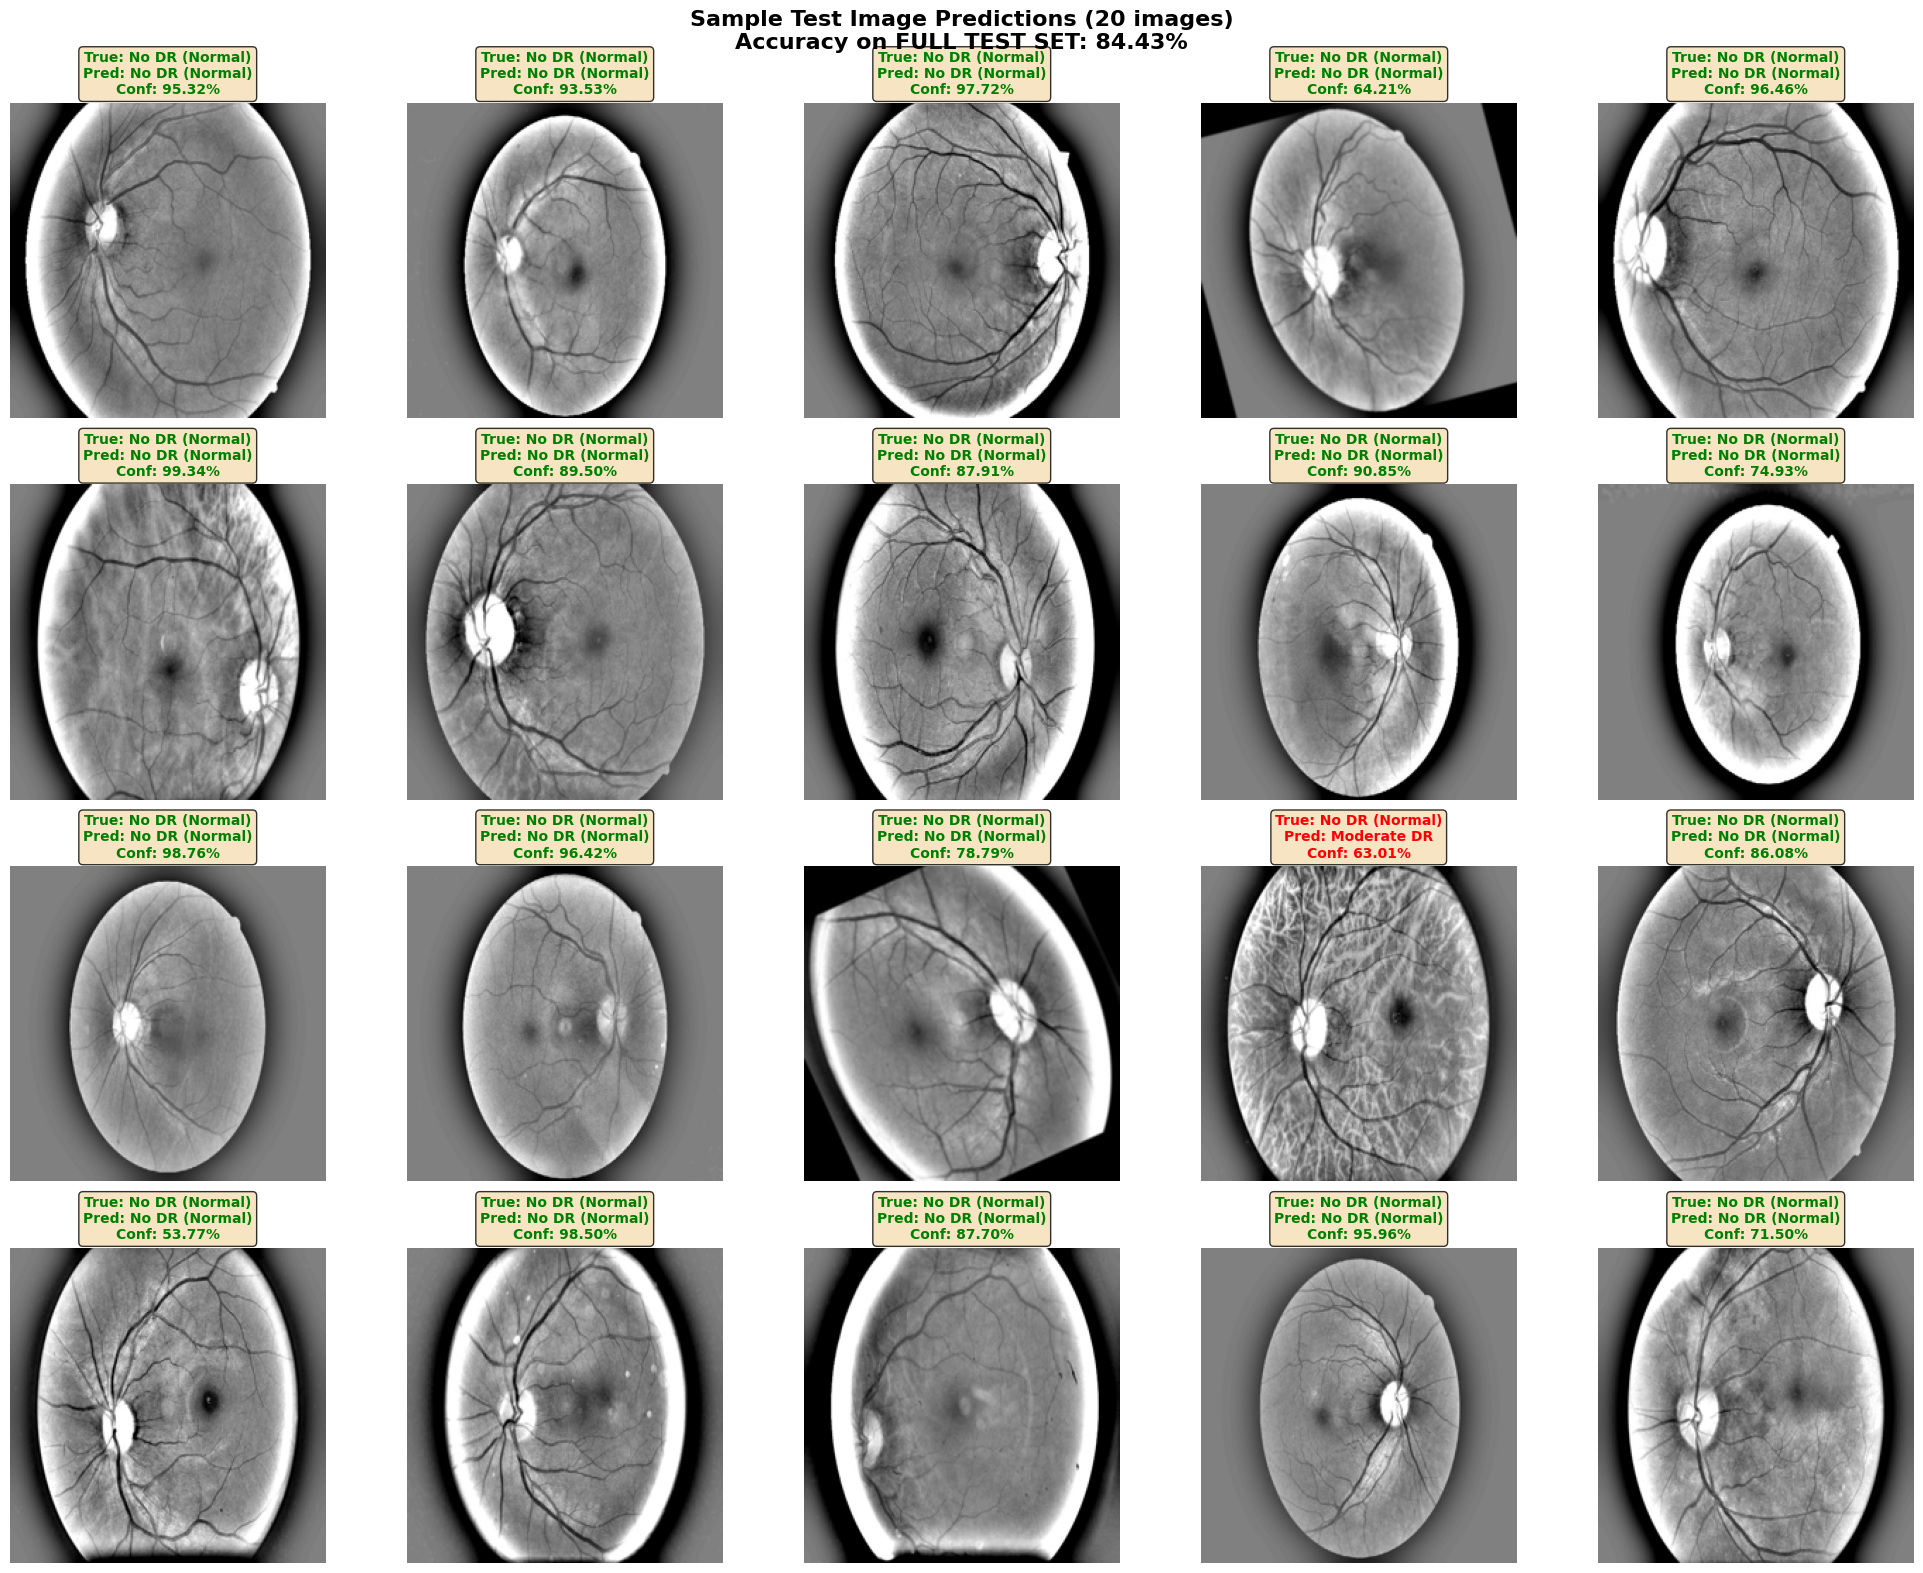

✓ Visualization saved: predictions_sample_20_images.png


In [11]:
print("\n" + "="*70)
print("CREATING VISUALIZATION (SAMPLE ONLY)")
print("="*70)

# Number of images to visualize
num_vis = 20

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

colors = ['green', 'red']  # Green = correct, Red = wrong

for i in range(num_vis):
    ax = axes[i]

    # Display image
    ax.imshow(loaded_images[i])

    true_stage = DR_STAGES[true_classes_array[i]]
    pred_stage = DR_STAGES[predicted_classes[i]]
    confidence = confidences[i]
    is_correct = true_classes_array[i] == predicted_classes[i]

    color = colors[0] if is_correct else colors[1]
    title = f"True: {true_stage}\nPred: {pred_stage}\nConf: {confidence:.2%}"

    ax.set_title(
        title,
        fontsize=10,
        fontweight='bold',
        color=color,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.axis('off')

plt.suptitle(
    f'Sample Test Image Predictions (20 images)\n'
    f'Accuracy on FULL TEST SET: {accuracy:.2f}%',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig("predictions_sample_20_images.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved: predictions_sample_20_images.png")


In [13]:
# ============================================================================
# CELL: EVALUATION METRICS (FULL TEST DATASET)
# ============================================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
import numpy as np
import pandas as pd

print("\n" + "="*70)
print("EVALUATION METRICS")
print("="*70)



EVALUATION METRICS


In [14]:
# -------------------------------
# 1. Overall Accuracy
# -------------------------------
accuracy = accuracy_score(true_classes_array, predicted_classes) * 100
print(f"Overall Accuracy: {accuracy:.2f}%")


Overall Accuracy: 84.43%


In [15]:
# -------------------------------
# 2. Precision, Recall, F1-score per class
# -------------------------------
precision, recall, f1, support = precision_recall_fscore_support(
    true_classes_array,
    predicted_classes,
    labels=[0, 1, 2, 3, 4],
    zero_division=0
)

metrics_df = pd.DataFrame({
    "Class": [DR_STAGES[i] for i in range(5)],
    "Precision (%)": precision * 100,
    "Recall / Sensitivity (%)": recall * 100,
    "F1-Score (%)": f1 * 100,
    "Support": support
})

print("\nPer-Class Metrics:")
print(metrics_df.round(2))


Per-Class Metrics:
              Class  Precision (%)  Recall / Sensitivity (%)  F1-Score (%)  \
0    No DR (Normal)          67.00                     74.50         70.55   
1           Mild DR          83.39                     77.55         80.36   
2       Moderate DR          75.48                     71.40         73.38   
3         Severe DR          98.30                     98.50         98.40   
4  Proliferative DR          99.21                    100.00         99.60   

   Support  
0     1000  
1      971  
2     1000  
3     1000  
4     1000  


In [16]:
# -------------------------------
# 3. Classification Report (Text)
# -------------------------------
print("\nDetailed Classification Report:")
print(
    classification_report(
        true_classes_array,
        predicted_classes,
        target_names=[DR_STAGES[i] for i in range(5)],
        digits=4
    )
)


Detailed Classification Report:
                  precision    recall  f1-score   support

  No DR (Normal)     0.6700    0.7450    0.7055      1000
         Mild DR     0.8339    0.7755    0.8036       971
     Moderate DR     0.7548    0.7140    0.7338      1000
       Severe DR     0.9830    0.9850    0.9840      1000
Proliferative DR     0.9921    1.0000    0.9960      1000

        accuracy                         0.8443      4971
       macro avg     0.8467    0.8439    0.8446      4971
    weighted avg     0.8468    0.8443    0.8448      4971



In [17]:
# -------------------------------
# 4. Confusion Matrix
# -------------------------------
cm = confusion_matrix(true_classes_array, predicted_classes)

cm_df = pd.DataFrame(
    cm,
    index=[f"True: {DR_STAGES[i]}" for i in range(5)],
    columns=[f"Pred: {DR_STAGES[i]}" for i in range(5)]
)

print("\nConfusion Matrix:")
print(cm_df)


Confusion Matrix:
                        Pred: No DR (Normal)  Pred: Mild DR  \
True: No DR (Normal)                     745             95   
True: Mild DR                            153            753   
True: Moderate DR                        214             55   
True: Severe DR                            0              0   
True: Proliferative DR                     0              0   

                        Pred: Moderate DR  Pred: Severe DR  \
True: No DR (Normal)                  155                2   
True: Mild DR                          62                3   
True: Moderate DR                     714               12   
True: Severe DR                        15              985   
True: Proliferative DR                  0                0   

                        Pred: Proliferative DR  
True: No DR (Normal)                         3  
True: Mild DR                                0  
True: Moderate DR                            5  
True: Severe DR                  

In [18]:
# -------------------------------
# 5. Medical-Critical Sensitivity
# -------------------------------
print("\nMedical-Critical Sensitivity (Recall):")
print(f"Severe DR Recall:         {recall[3]*100:.2f}%")
print(f"Proliferative DR Recall:  {recall[4]*100:.2f}%")


Medical-Critical Sensitivity (Recall):
Severe DR Recall:         98.50%
Proliferative DR Recall:  100.00%


In [2]:
# ============================================================================
# CONVERT KERAS MODEL TO TFLITE FOR ANDROID APP
# ============================================================================

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os

print("="*70)
print("KERAS TO TFLITE CONVERSION")
print("="*70)
print("Converting Model 1 (EfficientNetB2 + ViT) to TFLite format\n")


KERAS TO TFLITE CONVERSION
Converting Model 1 (EfficientNetB2 + ViT) to TFLite format



In [3]:
# ============================================================================
# CELL 1: Define Custom Layers
# ============================================================================
class ClassToken(layers.Layer):
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim), 
            initializer="zeros", 
            trainable=True, 
            name="cls_token"
        )
    
    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        return tf.concat([cls_tokens, x], axis=1)
    
    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim})
        return config


class PositionalEmbedding(layers.Layer):
    def __init__(self, n_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.n_patches = n_patches
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(self.n_patches + 1, self.embed_dim), 
            initializer="random_normal", 
            trainable=True, 
            name="pos_emb"
        )
    
    def call(self, x):
        return x + self.pos_emb
    
    def get_config(self):
        config = super().get_config()
        config.update({"n_patches": self.n_patches, "embed_dim": self.embed_dim})
        return config


print("✓ Custom layers defined")



✓ Custom layers defined


In [5]:
# ============================================================================
# CELL 2: Load Keras Model
# ============================================================================
print("\n" + "="*70)
print("LOADING KERAS MODEL")
print("="*70)

model_path = "/kaggle/input/model3-finetuned2/keras/default/1/best_continued_model.keras"

try:
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            'ClassToken': ClassToken,
            'PositionalEmbedding': PositionalEmbedding
        }
    )
    print(f"✓ Model loaded successfully!")
    print(f"✓ Model: best_continued_model.keras")
    print(f"✓ Parameters: {model.count_params():,}")
    print(f"✓ Input shape: {model.input_shape}")
    print(f"✓ Output shape: {model.output_shape}")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    raise


LOADING KERAS MODEL


I0000 00:00:1766985381.543681      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766985381.544316      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✓ Model loaded successfully!
✓ Model: best_continued_model.keras
✓ Parameters: 20,257,022
✓ Input shape: (None, 224, 224, 3)
✓ Output shape: (None, 5)


In [6]:
# ============================================================================
# CELL 3: Create Output Directory
# ============================================================================
print("\n" + "="*70)
print("CREATING OUTPUT DIRECTORY")
print("="*70)

os.makedirs("tflite_models", exist_ok=True)
print("✓ Directory created: tflite_models/")




CREATING OUTPUT DIRECTORY
✓ Directory created: tflite_models/


In [7]:
print("\n" + "="*70)
print("CONVERTING TO TFLITE (STANDARD)")
print("="*70)

try:
    # Create TFLite converter
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    # Standard conversion
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    
    # Convert
    tflite_model = converter.convert()
    
    # Save
    tflite_path = "tflite_models/diabetic_retinopathy_model.tflite"
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    
    file_size = os.path.getsize(tflite_path) / (1024 * 1024)  # MB
    print(f"✓ Standard TFLite model saved!")
    print(f"  Path: {tflite_path}")
    print(f"  Size: {file_size:.2f} MB")
    
except Exception as e:
    print(f"✗ Error during standard conversion: {e}")




CONVERTING TO TFLITE (STANDARD)
INFO:tensorflow:Assets written to: /tmp/tmpn1l_0rl2/assets


INFO:tensorflow:Assets written to: /tmp/tmpn1l_0rl2/assets


Saved artifact at '/tmp/tmpn1l_0rl2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134544205724368: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134544205719568: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134544203465552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203465360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203468240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203467856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203468624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203468048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203465936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203470160: TensorSpec(shape=(), dtype=tf.resource, name=Non

W0000 00:00:1766985441.244590      47 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1766985441.244643      47 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1766985441.580089      47 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


✓ Standard TFLite model saved!
  Path: tflite_models/diabetic_retinopathy_model.tflite
  Size: 77.05 MB


In [8]:
# ============================================================================
# CELL 5: Convert to TFLite (Quantized - Smaller)
# ============================================================================
print("\n" + "="*70)
print("CONVERTING TO TFLITE (QUANTIZED - SMALLER)")
print("="*70)

try:
    # Create TFLite converter with quantization
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    # Enable quantization
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    
    # Target specs
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    
    # Convert
    tflite_quant_model = converter.convert()
    
    # Save
    tflite_quant_path = "tflite_models/diabetic_retinopathy_model_quantized.tflite"
    with open(tflite_quant_path, 'wb') as f:
        f.write(tflite_quant_model)
    
    file_size_quant = os.path.getsize(tflite_quant_path) / (1024 * 1024)  # MB
    print(f"✓ Quantized TFLite model saved!")
    print(f"  Path: {tflite_quant_path}")
    print(f"  Size: {file_size_quant:.2f} MB")
    
except Exception as e:
    print(f"✗ Error during quantized conversion: {e}")



CONVERTING TO TFLITE (QUANTIZED - SMALLER)
INFO:tensorflow:Assets written to: /tmp/tmp6rdy49we/assets


INFO:tensorflow:Assets written to: /tmp/tmp6rdy49we/assets


Saved artifact at '/tmp/tmp6rdy49we'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134544205724368: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134544205719568: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134544203465552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203465360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203468240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203467856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203468624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203468048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203465936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134544203470160: TensorSpec(shape=(), dtype=tf.resource, name=Non

W0000 00:00:1766985476.843280      47 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1766985476.843316      47 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✓ Quantized TFLite model saved!
  Path: tflite_models/diabetic_retinopathy_model_quantized.tflite
  Size: 20.55 MB


In [9]:
# ============================================================================
# CELL 7: Test TFLite Model
# ============================================================================
print("\n" + "="*70)
print("TESTING TFLITE MODEL")
print("="*70)

try:
    # Load TFLite model
    interpreter = tf.lite.Interpreter(model_path="tflite_models/diabetic_retinopathy_model.tflite")
    interpreter.allocate_tensors()
    
    # Get input and output details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print("✓ TFLite model loaded successfully!")
    print(f"\nInput Details:")
    print(f"  Name: {input_details[0]['name']}")
    print(f"  Shape: {input_details[0]['shape']}")
    print(f"  Type: {input_details[0]['dtype']}")
    
    print(f"\nOutput Details:")
    print(f"  Name: {output_details[0]['name']}")
    print(f"  Shape: {output_details[0]['shape']}")
    print(f"  Type: {output_details[0]['dtype']}")
    
    # Test with random input
    print("\n✓ Running test inference...")
    test_input = np.random.rand(1, 224, 224, 3).astype(np.float32)
    
    interpreter.set_tensor(input_details[0]['index'], test_input)
    interpreter.invoke()
    
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_class = np.argmax(output_data[0])
    confidence = np.max(output_data[0])
    
    print(f"✓ Test inference successful!")
    print(f"  Predicted class: {predicted_class}")
    print(f"  Confidence: {confidence:.2%}")
    print(f"  All outputs: {output_data[0]}")
    
except Exception as e:
    print(f"✗ Error testing TFLite: {e}")




TESTING TFLITE MODEL
✓ TFLite model loaded successfully!

Input Details:
  Name: serving_default_input_layer_2:0
  Shape: [  1 224 224   3]
  Type: <class 'numpy.float32'>

Output Details:
  Name: StatefulPartitionedCall_1:0
  Shape: [1 5]
  Type: <class 'numpy.float32'>

✓ Running test inference...
✓ Test inference successful!
  Predicted class: 0
  Confidence: 99.92%
  All outputs: [9.9924564e-01 5.8177651e-08 7.4931164e-04 3.9154751e-09 5.0563417e-06]


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


### Boost accuracy

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

print("="*70)
print("ACCURACY BOOST: 84% → 90-95%")
print("="*70)


2025-12-29 12:50:58.372993: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767012658.597929      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767012658.660534      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

ACCURACY BOOST: 84% → 90-95%


In [2]:
DR_STAGES = {
    0: 'No DR (Normal)',
    1: 'Mild DR',
    2: 'Moderate DR',
    3: 'Severe DR',
    4: 'Proliferative DR'
}

print("✓ DR Stages ready")


✓ DR Stages ready


In [3]:
class ClassToken(layers.Layer):
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim), 
            initializer="zeros", 
            trainable=True, 
            name="cls_token"
        )
    
    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        return tf.concat([cls_tokens, x], axis=1)
    
    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim})
        return config


class PositionalEmbedding(layers.Layer):
    def __init__(self, n_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.n_patches = n_patches
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(self.n_patches + 1, self.embed_dim), 
            initializer="random_normal", 
            trainable=True, 
            name="pos_emb"
        )
    
    def call(self, x):
        return x + self.pos_emb
    
    def get_config(self):
        config = super().get_config()
        config.update({"n_patches": self.n_patches, "embed_dim": self.embed_dim})
        return config


print("✓ Custom layers defined")



✓ Custom layers defined


In [4]:
print("\n" + "="*70)
print("LOADING MODEL + DATA")
print("="*70)

model_path = "/kaggle/input/model3-finetuned2/keras/default/1/best_continued_model.keras"

model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        'ClassToken': ClassToken,
        'PositionalEmbedding': PositionalEmbedding
    }
)

print("✓ Model loaded")


LOADING MODEL + DATA


I0000 00:00:1767012688.284303      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767012688.284935      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✓ Model loaded


In [5]:
print("\n" + "="*70)
print("LOADING DATA - MODERATE AUGMENTATION")
print("="*70)

train_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/train"
val_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/val"
test_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/test"

# MODERATE augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    channel_shift_range=20,
    fill_mode='reflect'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 24  # Bigger batch = more stable

train_ds = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=batch_size, 
    class_mode='categorical', shuffle=True, seed=42
)

val_ds = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=batch_size, 
    class_mode='categorical', shuffle=False
)

test_ds = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=batch_size, 
    class_mode='categorical', shuffle=False
)

print(f"✓ Data loaded (batch_size={batch_size})")



LOADING DATA - MODERATE AUGMENTATION
Found 34792 images belonging to 5 classes.
Found 9940 images belonging to 5 classes.
Found 4971 images belonging to 5 classes.
✓ Data loaded (batch_size=24)


In [6]:
print("\n" + "="*70)
print("BASELINE CHECK")
print("="*70)

# Baseline accuracy check karo (training se pehle)
print("\n📊 Evaluating model on test data...")
baseline_loss, baseline_acc = model.evaluate(test_ds, verbose=1)

print("\n" + "="*70)
print("BASELINE RESULTS")
print("="*70)
print(f"📌 Baseline Loss:     {baseline_loss:.4f}")
print(f"📌 Baseline Accuracy: {baseline_acc*100:.2f}%")
print("="*70)

# Analysis
print("\n🔍 ANALYSIS:")
if baseline_acc >= 0.84:
    print("✅ EXCELLENT! Model pehle se hi acha hai!")
    print("   → Fine-tuning se 90%+ ho sakta hai")
elif baseline_acc >= 0.70:
    print("✓ GOOD! Solid baseline hai")
    print("   → Fine-tuning se improvement hoga")
elif baseline_acc >= 0.50:
    print("⚠️ AVERAGE - Improvement ki zaroorat hai")
    print("   → Carefully training karen")
else:
    print("❌ LOW BASELINE! Problem ho sakti hai:")
    print("   → Check learning rate")
    print("   → Check if model sahi load hua")
    print("   → Data preprocessing check karen")

print("\n💡 Ab is baseline se aage improve karenge!")
print("="*70)


BASELINE CHECK

📊 Evaluating model on test data...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1767012949.288724     111 service.cc:148] XLA service 0x7b2ba4818950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767012949.289669     111 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767012949.289696     111 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767012950.401827     111 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/208 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.8333 - loss: 0.4857 

I0000 00:00:1767012957.910134     111 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


208/208 ━━━━━━━━━━━━━━━━━━━━ 55s 195ms/step - accuracy: 0.7766 - loss: 0.6473

BASELINE RESULTS
📌 Baseline Loss:     0.4882
📌 Baseline Accuracy: 83.12%

🔍 ANALYSIS:
✓ GOOD! Solid baseline hai
   → Fine-tuning se improvement hoga

💡 Ab is baseline se aage improve karenge!


In [7]:
print("\n" + "="*70)
print("AGGRESSIVE UNFREEZING - ALL LAYERS")
print("="*70)

# Unfreeze EVERYTHING
for layer in model.layers:
    layer.trainable = True

trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
total_params = model.count_params()

print(f"✓ ALL layers trainable!")
print(f"  Trainable: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")


AGGRESSIVE UNFREEZING - ALL LAYERS
✓ ALL layers trainable!
  Trainable: 20,189,447 (99.7%)


In [8]:
print("\n" + "="*70)
print("COMPILE - BALANCED APPROACH")
print("="*70)

# Use medium learning rate (NOT too low)
learning_rate = 1e-5  # Higher than before (1e-7 was too low)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=learning_rate,
        beta_1=0.9,
        beta_2=0.999
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✓ Compiled:")
print(f"  Learning Rate: {learning_rate} (MEDIUM - more aggressive)")
print(f"  All layers: TRAINABLE")




COMPILE - BALANCED APPROACH
✓ Compiled:
  Learning Rate: 1e-05 (MEDIUM - more aggressive)
  All layers: TRAINABLE


In [9]:

print("\n" + "="*70)
print("CALLBACKS - AGGRESSIVE")
print("="*70)

import os
os.makedirs("final_90plus", exist_ok=True)

# Aggressive LR schedule
def lr_schedule(epoch, lr):
    if epoch < 3:
        return lr  # Keep stable
    elif epoch < 6:
        return lr * 0.95  # Slow decrease
    else:
        return lr * 0.9   # Decrease

lr_schedule_cb = LearningRateScheduler(lr_schedule, verbose=0)

checkpoint = ModelCheckpoint(
    "final_90plus/best_90_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.8,
    patience=1,  # AGGRESSIVE - reduce after 1 epoch of no improvement
    min_lr=1e-6,
    verbose=1,
    mode="max"
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,  # Stop if no improvement for 5 epochs
    restore_best_weights=True,
    verbose=1,
    mode="max",
    min_delta=0.001  # Minimum improvement = 0.1%
)

callbacks = [checkpoint, lr_schedule_cb, lr_reduce, early_stop]

print("✓ Callbacks configured (AGGRESSIVE)")


CALLBACKS - AGGRESSIVE
✓ Callbacks configured (AGGRESSIVE)


In [10]:
print("\n" + "="*70)
print("🚀 AGGRESSIVE TRAINING: 83% → 90%+")
print("="*70)
print(f"Start: {datetime.now().strftime('%H:%M:%S')}")
print(f"Current: 83.08%")
print(f"Target: 90%+")
print(f"Strategy: All layers + Medium LR + More aggressive")
print("="*70 + "\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,  # More epochs
    callbacks=callbacks,
    verbose=1
)


🚀 AGGRESSIVE TRAINING: 83% → 90%+
Start: 12:57:04
Current: 83.08%
Target: 90%+
Strategy: All layers + Medium LR + More aggressive

Epoch 1/30


E0000 00:00:1767013101.541004     114 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767013101.683882     114 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767013102.142860     114 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767013102.286425     114 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 294/1450 ━━━━━━━━━━━━━━━━━━━━ 9:08 475ms/step - accuracy: 0.8746 - loss: 0.3139

E0000 00:00:1767013300.318892     111 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767013300.459305     111 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767013300.816269     111 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767013300.959824     111 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8744 - loss: 0.3117
Epoch 1: val_accuracy improved from -inf to 0.33421, saving model to final_90plus/best_90_model.keras
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 947s 573ms/step - accuracy: 0.8744 - loss: 0.3117 - val_accuracy: 0.3342 - val_loss: 4.8766 - learning_rate: 1.0000e-05
Epoch 2/30
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8832 - loss: 0.2898
Epoch 2: val_accuracy improved from 0.33421 to 0.69557, saving model to final_90plus/best_90_model.keras
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 577s 397ms/step - accuracy: 0.8832 - loss: 0.2898 - val_accuracy: 0.6956 - val_loss: 1.1371 - learning_rate: 1.0000e-05
Epoch 3/30
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8854 - loss: 0.2829
Epoch 3: val_accuracy improved from 0.69557 to 0.81217, saving model to final_90plus/best_90_model.keras
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 580s 400ms/step - accuracy: 0.8854 - loss: 0.2829 - val_accuracy: 0.8122 - val_loss: 0.5560 - le

In [25]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize

In [21]:
IMG_SIZE = 224
BATCH_SIZE = 32

MODEL_PATH = "/kaggle/working/final_90plus/best_90_model.keras"
TEST_DIR  = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/test"

DR_STAGES = [
    "No DR",
    "Mild DR",
    "Moderate DR",
    "Severe DR",
    "Proliferative DR"
]

In [22]:
print("\n" + "="*70)
print("LOADING MODEL")
print("="*70)

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "ClassToken": ClassToken,
        "PositionalEmbedding": PositionalEmbedding
    }
)

print("✓ Model loaded")
print(f"✓ Parameters: {model.count_params():,}")


LOADING MODEL
✓ Model loaded
✓ Parameters: 20,257,022


In [23]:
# ============================================================================
# LOAD TEST IMAGES (FULL DATASET)
# ============================================================================
print("\n" + "="*70)
print("LOADING TEST DATASET")
print("="*70)

image_paths = []
true_labels = []

for class_id in sorted(os.listdir(TEST_DIR)):
    class_path = os.path.join(TEST_DIR, class_id)
    if not os.path.isdir(class_path):
        continue

    class_id = int(class_id)

    for img_name in os.listdir(class_path):
        if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(class_path, img_name))
            true_labels.append(class_id)

print(f"✓ Total test images: {len(image_paths)}")


LOADING TEST DATASET
✓ Total test images: 4971


In [26]:
# ============================================================================
# PREPROCESS IMAGES
# ============================================================================
print("\n" + "="*70)
print("PREPROCESSING IMAGES")
print("="*70)

images = []

for i, path in enumerate(image_paths):
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.asarray(img, dtype=np.float32) / 255.0
    images.append(img)

    if (i + 1) % 200 == 0:
        print(f"  Loaded {i+1}/{len(image_paths)}")

images = np.array(images)
true_labels = np.array(true_labels)

print("✓ Preprocessing complete")


PREPROCESSING IMAGES
  Loaded 200/4971
  Loaded 400/4971
  Loaded 600/4971
  Loaded 800/4971
  Loaded 1000/4971
  Loaded 1200/4971
  Loaded 1400/4971
  Loaded 1600/4971
  Loaded 1800/4971
  Loaded 2000/4971
  Loaded 2200/4971
  Loaded 2400/4971
  Loaded 2600/4971
  Loaded 2800/4971
  Loaded 3000/4971
  Loaded 3200/4971
  Loaded 3400/4971
  Loaded 3600/4971
  Loaded 3800/4971
  Loaded 4000/4971
  Loaded 4200/4971
  Loaded 4400/4971
  Loaded 4600/4971
  Loaded 4800/4971
✓ Preprocessing complete


In [27]:
# ============================================================================
# PREDICTIONS
# ============================================================================
print("\n" + "="*70)
print("RUNNING INFERENCE")
print("="*70)

pred_probs = model.predict(images, batch_size=BATCH_SIZE, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)


RUNNING INFERENCE
156/156 ━━━━━━━━━━━━━━━━━━━━ 34s 140ms/step


In [28]:
# ============================================================================
# TEST ACCURACY
# ============================================================================
accuracy = accuracy_score(true_labels, pred_labels) * 100
print(f"\n✅ TEST ACCURACY: {accuracy:.2f}%")


✅ TEST ACCURACY: 84.99%


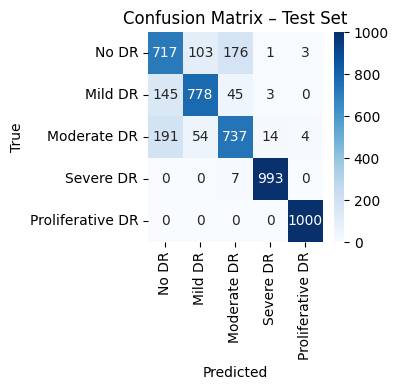

In [30]:

# ============================================================================
# CONFUSION MATRIX
# ============================================================================
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=DR_STAGES,
    yticklabels=DR_STAGES
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Test Set")
plt.tight_layout()
plt.show()

In [31]:
# ============================================================================
# PRECISION / RECALL / F1
# ============================================================================
precision, recall, f1, support = precision_recall_fscore_support(
    true_labels,
    pred_labels,
    labels=[0,1,2,3,4],
    zero_division=0
)

metrics_df = pd.DataFrame({
    "Class": DR_STAGES,
    "Precision (%)": precision * 100,
    "Recall / Sensitivity (%)": recall * 100,
    "F1-score (%)": f1 * 100,
    "Support": support
})

print("\nPER-CLASS METRICS")
print(metrics_df.round(2))


PER-CLASS METRICS
              Class  Precision (%)  Recall / Sensitivity (%)  F1-score (%)  \
0             No DR          68.09                     71.70         69.85   
1           Mild DR          83.21                     80.12         81.64   
2       Moderate DR          76.37                     73.70         75.01   
3         Severe DR          98.22                     99.30         98.76   
4  Proliferative DR          99.30                    100.00         99.65   

   Support  
0     1000  
1      971  
2     1000  
3     1000  
4     1000  


In [32]:

# ============================================================================
# SENSITIVITY & SPECIFICITY (MEDICAL)
# ============================================================================
def sensitivity_specificity(cm):
    sens, spec = [], []
    for i in range(len(cm)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)

        sens.append(TP / (TP + FN + 1e-8))
        spec.append(TN / (TN + FP + 1e-8))
    return sens, spec

sens, spec = sensitivity_specificity(cm)

medical_df = pd.DataFrame({
    "Class": DR_STAGES,
    "Sensitivity (%)": np.array(sens) * 100,
    "Specificity (%)": np.array(spec) * 100
})

print("\nMEDICAL METRICS")
print(medical_df.round(2))


MEDICAL METRICS
              Class  Sensitivity (%)  Specificity (%)
0             No DR            71.70            91.54
1           Mild DR            80.12            96.07
2       Moderate DR            73.70            94.26
3         Severe DR            99.30            99.55
4  Proliferative DR           100.00            99.82


In [33]:
# ============================================================================
# MEDICAL-CRITICAL CLASSES
# ============================================================================
print("\nMEDICAL-CRITICAL PERFORMANCE")
print("="*40)
print(f"Severe DR Sensitivity:        {sens[3]*100:.2f}%")
print(f"Proliferative DR Sensitivity: {sens[4]*100:.2f}%")


MEDICAL-CRITICAL PERFORMANCE
Severe DR Sensitivity:        99.30%
Proliferative DR Sensitivity: 100.00%


### Conversion to .tflite

In [6]:
# ============================================================================
# CONVERT KERAS MODEL TO TFLITE FOR ANDROID APP
# ============================================================================

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os

print("="*70)
print("KERAS TO TFLITE CONVERSION")

KERAS TO TFLITE CONVERSION


In [7]:
print("\n" + "="*70)
print("LOADING KERAS MODEL")
print("="*70)

model_path = "/kaggle/input/final/keras/default/1/best_90_model.keras"

try:
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            'ClassToken': ClassToken,
            'PositionalEmbedding': PositionalEmbedding
        }
    )
    print(f"✓ Model loaded successfully!")
    print(f"✓ Model: best_continued_model.keras")
    print(f"✓ Parameters: {model.count_params():,}")
    print(f"✓ Input shape: {model.input_shape}")
    print(f"✓ Output shape: {model.output_shape}")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    raise




LOADING KERAS MODEL


I0000 00:00:1767329988.307843      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767329988.308662      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✓ Model loaded successfully!
✓ Model: best_continued_model.keras
✓ Parameters: 20,257,022
✓ Input shape: (None, 224, 224, 3)
✓ Output shape: (None, 5)


In [8]:
print("\n" + "="*70)
print("CREATING OUTPUT DIRECTORY")
print("="*70)

os.makedirs("tflite_models", exist_ok=True)
print("✓ Directory created: tflite_models/")


CREATING OUTPUT DIRECTORY
✓ Directory created: tflite_models/


In [9]:
print("\n" + "="*70)
print("CONVERTING TO TFLITE (STANDARD)")
print("="*70)

try:
    # Create TFLite converter
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    # Standard conversion
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    
    # Convert
    tflite_model = converter.convert()
    
    # Save
    tflite_path = "tflite_models/diabetic_retinopathy_model.tflite"
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    
    file_size = os.path.getsize(tflite_path) / (1024 * 1024)  # MB
    print(f"✓ Standard TFLite model saved!")
    print(f"  Path: {tflite_path}")
    print(f"  Size: {file_size:.2f} MB")
    
except Exception as e:
    print(f"✗ Error during standard conversion: {e}")




CONVERTING TO TFLITE (STANDARD)
INFO:tensorflow:Assets written to: /tmp/tmpgbgg3z5w/assets


INFO:tensorflow:Assets written to: /tmp/tmpgbgg3z5w/assets


Saved artifact at '/tmp/tmpgbgg3z5w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  139035813593936: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139035813594320: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139037561758992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139037561756688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139037561759760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139037561759376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139037561760144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139037561760336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139037561760720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139037561761872: TensorSpec(shape=(), dtype=tf.resource, name=Non

W0000 00:00:1767330050.245975      47 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1767330050.246024      47 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1767330050.575271      47 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


✓ Standard TFLite model saved!
  Path: tflite_models/diabetic_retinopathy_model.tflite
  Size: 77.05 MB


### CLient 2

In [12]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
# ============================================================================
# CELL 2: Define Paths for Gaussian Filtered Dataset
# ============================================================================
base_dir = "/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images"

# Class folders
class_dirs = {
    0: os.path.join(base_dir, "No_DR"),
    1: os.path.join(base_dir, "Mild"),
    2: os.path.join(base_dir, "Moderate"),
    3: os.path.join(base_dir, "Severe"),
    4: os.path.join(base_dir, "Proliferate_DR")
}

print("="*70)
print("CLIENT-2: GAUSSIAN FILTERED DATASET PATHS")
print("="*70)
for class_id, path in class_dirs.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌"
    print(f"{status} Class {class_id}: {path}")
print("="*70)


CLIENT-2: GAUSSIAN FILTERED DATASET PATHS
✅ Class 0: /kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/No_DR
✅ Class 1: /kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Mild
✅ Class 2: /kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Moderate
✅ Class 3: /kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Severe
✅ Class 4: /kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Proliferate_DR


In [3]:
base_dir = "/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images"

# Since this dataset doesn't have separate train/val/test, we'll use all as training
train_dir = base_dir
val_dir = base_dir  # Same for now - in production would split
test_dir = base_dir

print("="*70)
print("CLIENT-2: GAUSSIAN FILTERED DATASET PATHS")
print("="*70)
print(f"Train: {train_dir}")
print(f"Val: {val_dir}")
print(f"Test: {test_dir}")
print("="*70)


CLIENT-2: GAUSSIAN FILTERED DATASET PATHS
Train: /kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images
Val: /kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images
Test: /kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images


In [4]:
def count_images(directory):
    """Count total images in directory"""
    total = 0
    class_counts = {}
    
    for root, dirs, files in os.walk(directory):
        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        total += len(image_files)
        
        # Count per class
        if root != directory:
            class_name = os.path.basename(root)
            class_counts[class_name] = len(image_files)
    
    return total, class_counts

train_samples, train_classes = count_images(train_dir)

print("\n" + "="*70)
print("DATASET SIZE ANALYSIS")
print("="*70)
print(f"\nTrain samples: {train_samples}")
for cls, count in train_classes.items():
    print(f"  - {cls}: {count}")

print(f"\n{'='*70}")
print(f"TOTAL SAMPLES: {train_samples}")
print("="*70)



DATASET SIZE ANALYSIS

Train samples: 3662
  - Mild: 370
  - Proliferate_DR: 295
  - Moderate: 999
  - No_DR: 1805
  - Severe: 193

TOTAL SAMPLES: 3662


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("\nSetting up data generators...")

# Training data with augmentation (SAME as Client-1)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data without augmentation
val_datagen = ImageDataGenerator(rescale=1./255)

# Test data without augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

print("✓ Data generators created")


Setting up data generators...
✓ Data generators created


In [6]:
print("\nLoading datasets...")

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_ds = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(f"✓ Train dataset loaded: {train_ds.samples} samples")
print(f"✓ Validation dataset loaded: {val_ds.samples} samples")
print(f"✓ Test dataset loaded: {test_ds.samples} samples")
print(f"✓ Number of classes: {train_ds.num_classes}")
print(f"✓ Classes: {train_ds.class_indices}")



Loading datasets...
Found 3662 images belonging to 5 classes.
Found 3662 images belonging to 5 classes.
Found 3662 images belonging to 5 classes.
✓ Train dataset loaded: 3662 samples
✓ Validation dataset loaded: 3662 samples
✓ Test dataset loaded: 3662 samples
✓ Number of classes: 5
✓ Classes: {'Mild': 0, 'Moderate': 1, 'No_DR': 2, 'Proliferate_DR': 3, 'Severe': 4}


In [13]:
# ============================================================================
# CELL 6: Define Custom Layers
# ============================================================================
class ClassToken(layers.Layer):
    """Adds learnable class token"""
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer="zeros",
            trainable=True,
            name="cls_token"
        )
    
    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        return tf.concat([cls_tokens, x], axis=1)


class PositionalEmbedding(layers.Layer):
    """Adds learnable positional embeddings"""
    def __init__(self, n_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.n_patches = n_patches
        self.embed_dim = embed_dim
    
    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(self.n_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True,
            name="pos_emb"
        )
    
    def call(self, x):
        return x + self.pos_emb


In [14]:
# ============================================================================
# CELL 7: Define Transformer Encoder
# ============================================================================
def transformer_encoder(inputs, num_heads=4, embed_dim=384, mlp_dim=768, dropout=0.2):
    """Transformer encoder block"""
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.Add()([x, attn_out])
    y = layers.LayerNormalization(epsilon=1e-6)(x)
    y = layers.Dense(mlp_dim, activation='gelu')(y)
    y = layers.Dropout(dropout)(y)
    y = layers.Dense(embed_dim)(y)
    y = layers.Dropout(dropout)(y)
    return layers.Add()([x, y])


In [15]:
# ============================================================================
# CELL 8: Build Hybrid Model
# ============================================================================
def build_hybrid_model(num_classes=5, embedding_dim=384, num_transformer_blocks=4):
    """Build hybrid CNN + Vision Transformer model"""
    
    inputs = layers.Input(shape=(224, 224, 3))
    
    # CNN Backbone
    base = tf.keras.applications.EfficientNetB2(
        include_top=False,
        input_tensor=inputs,
        weights='imagenet'
    )
    
    x = base.output
    
    # Project to embedding dimension
    x = layers.Conv2D(embedding_dim, kernel_size=1, padding='same')(x)
    
    # Get patch dimensions
    H, W = x.shape[1], x.shape[2]
    n_patches = H * W
    
    # Reshape to sequence
    x = layers.Reshape((n_patches, embedding_dim))(x)
    
    # Add class token and positional embeddings
    x = ClassToken(embedding_dim)(x)
    x = PositionalEmbedding(n_patches, embedding_dim)(x)
    
    # Transformer blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, num_heads=4, embed_dim=embedding_dim)
    
    # Classification head
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="hybrid_efficientnet_vit")
    return model, base



In [10]:
print("\n" + "="*70)
print("LOADING GLOBAL MODEL FOR CLIENT-2")
print("="*70)
model_path ='/kaggle/input/final/keras/default/1/best_90_model.keras'
try:
    # Try loading aggregated global model from server first
    global_model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            'ClassToken': ClassToken,
            'PositionalEmbedding': PositionalEmbedding
        }
    )
    print("Loaded:model_round_1.keras")
except FileNotFoundError:
    try:
        # Fallback: Load Client-1 model as initial global model
        global_model = tf.keras.models.load_model('client_1_model.keras')
        print(" Loaded: client_1_model.keras (Client-1 initial model)")
    except FileNotFoundError:
        print(" ERROR: Could not find global model!")
        print("   Make sure one of these exists:")
        print("   - global_model_round_1.keras (from server)")
        print("   - client_1_model.keras (from client-1)")
        raise

print(f"Model name: {global_model.name}")
print("="*70)


LOADING GLOBAL MODEL FOR CLIENT-2


I0000 00:00:1767446693.608967      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767446693.609584      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Loaded:model_round_1.keras
Model name: hybrid_efficientnet_vit


In [14]:
print("\n" + "="*70)
print("DETERMINING FREEZING STRATEGY (FL-OPTIMIZED)")
print("="*70)
print(f"Total images in Client-2: {train_samples}")

if train_samples < 1000:
    strategy = "FREEZE_ALL"
    freeze_percentage = 100
    trainable_percentage = 0
    reason = "Very small dataset - prevent overfitting, keep global model intact"
    print(f"\n📊 Strategy: FREEZE_ALL (100% frozen)")
    
elif train_samples < 5000:
    strategy = "FREEZE_MOST"
    freeze_percentage = 95
    trainable_percentage = 5
    reason = "Small dataset - high freeze to prevent divergence from Client-1"
    print(f"\n📊 Strategy: FREEZE_MOST (~95% frozen, ~5% trainable)")
    
elif train_images < 10000:
    strategy = "FINETUNE_PARTIAL"
    freeze_percentage = 85
    trainable_percentage = 15
    reason = "Medium dataset - moderate freeze for stable FL aggregation"
    print(f"\n📊 Strategy: FINETUNE_PARTIAL (~85% frozen, ~15% trainable)")
    
elif train_images < 50000:
    strategy = "FINETUNE_SIGNIFICANT"
    freeze_percentage = 70
    trainable_percentage = 30
    reason = "Large dataset - allow more learning while maintaining FL compatibility"
    print(f"\n📊 Strategy: FINETUNE_SIGNIFICANT (~70% frozen, ~30% trainable)")
    
else:
    strategy = "FINETUNE_ALL"
    freeze_percentage = 50
    trainable_percentage = 50
    reason = "Very large dataset - can train more layers safely"
    print(f"\n📊 Strategy: FINETUNE_ALL (~50% frozen, ~50% trainable)")

print(f"\n📝 Reason: {reason}")
print(f"\n🔒 Freeze: {freeze_percentage}%")
print(f"🎯 Trainable: {trainable_percentage}%")
print("="*70)


DETERMINING FREEZING STRATEGY (FL-OPTIMIZED)
Total images in Client-2: 3662

📊 Strategy: FREEZE_MOST (~95% frozen, ~5% trainable)

📝 Reason: Small dataset - high freeze to prevent divergence from Client-1

🔒 Freeze: 95%
🎯 Trainable: 5%


In [15]:
# ============================================================================
# CELL 9: Build and Apply Freezing Strategy (FL-OPTIMIZED)
# ============================================================================
print("\n" + "="*70)
print(f"BUILDING MODEL WITH STRATEGY: {strategy}")
print("="*70)

model, base = build_hybrid_model(num_classes=train_ds.num_classes)

total_layers = len(base.layers)
print(f"\nTotal layers in backbone: {total_layers}")

# ============================================================================
# FL-OPTIMIZED FREEZING LOGIC
# ============================================================================

if strategy == "FREEZE_ALL":
    print("\n✓ STRATEGY: FREEZE_ALL")
    print("  Freezing entire backbone (100% frozen)...")
    freeze_percentage = 100
    freeze_until = total_layers
    learning_rate = 1e-4
    
elif strategy == "FREEZE_MOST":
    print("\n✓ STRATEGY: FREEZE_MOST")
    print("  Freezing ~95% of layers (FL-optimized)...")
    freeze_percentage = 95
    freeze_until = int(total_layers * 0.95)
    print(f"  Freezing first {freeze_until} layers...")
    learning_rate = 5e-5
    
elif strategy == "FINETUNE_PARTIAL":
    print("\n✓ STRATEGY: FINETUNE_PARTIAL")
    print("  Freezing ~85% of layers...")
    freeze_percentage = 85
    freeze_until = int(total_layers * 0.85)
    print(f"  Freezing first {freeze_until} layers...")
    learning_rate = 3e-5
    
else:  # FINETUNE_ALL or FINETUNE_SIGNIFICANT
    print(f"\n✓ STRATEGY: {strategy}")
    print("  Freezing ~70% of layers...")
    freeze_percentage = 70
    freeze_until = int(total_layers * 0.70)
    print(f"  Freezing first {freeze_until} layers...")
    learning_rate = 1e-5

# ============================================================================
# APPLY FREEZING TO BACKBONE LAYERS
# ============================================================================
print(f"\nApplying freezing strategy...")
print(f"Freeze first {freeze_until} layers, keep last {total_layers - freeze_until} trainable")

for i, layer in enumerate(base.layers):
    if i < freeze_until:
        layer.trainable = False
    else:
        layer.trainable = True

# ============================================================================
# RECOMPILE MODEL AFTER FREEZING
# ============================================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================================
# COUNT PARAMETERS (ACCURATE)
# ============================================================================
trainable = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])
total = model.count_params()

trainable_pct = (100 * trainable / total)
frozen_pct = (100 * non_trainable / total)

print("\n" + "="*70)
print("PARAMETER SUMMARY (FL-OPTIMIZED)")
print("="*70)
print(f"Strategy: {strategy}")
print(f"Freeze percentage: {freeze_percentage}%")
print(f"\nTrainable parameters: {trainable:,} ({trainable_pct:.1f}%)")
print(f"Frozen parameters: {non_trainable:,} ({frozen_pct:.1f}%)")
print(f"Total parameters: {total:,}")
print(f"Learning rate: {learning_rate}")
print(f"\n✅ FL Stability: HIGH (weights stable for aggregation)")
print("="*70)


BUILDING MODEL WITH STRATEGY: FREEZE_MOST
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Total layers in backbone: 340

✓ STRATEGY: FREEZE_MOST
  Freezing ~95% of layers (FL-optimized)...
  Freezing first 323 layers...

Applying freezing strategy...
Freeze first 323 layers, keep last 17 trainable

PARAMETER SUMMARY (FL-OPTIMIZED)
Strategy: FREEZE_MOST
Freeze percentage: 95%

Trainable parameters: 14,132,381 (69.8%)
Frozen parameters: 6,124,641.0 (30.2%)
Total parameters: 20,257,022
Learning rate: 5e-05

✅ FL Stability: HIGH (weights stable for aggregation)


In [30]:
# ============================================================================
# CELL 10: Compile Model
# ============================================================================
print("\nCompiling model...")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


print(" Model compiled!")


Compiling model...
 Model compiled!


In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
# ============================================================================
# CELL 11: Setup Callbacks
# ============================================================================
os.makedirs("saved_models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath="saved_models/client2(1)_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, lr_reduce, early_stop]

print(" Callbacks configured!")

 Callbacks configured!


In [17]:
from datetime import datetime

# ============================================================================
# CELL 12: Train Model
# ============================================================================
print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Train batches: {len(train_ds)}")
print(f"Val batches: {len(val_ds)}")
print("="*70 + "\n")

history = global_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)



STARTING TRAINING
Start time: 2026-01-03 13:26:22
Train batches: 115
Val batches: 115



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/80


I0000 00:00:1767446826.171494     135 service.cc:148] XLA service 0x7861080033e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767446826.172874     135 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767446826.172894     135 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767446834.607692     135 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1767446850.132551     135 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767446850.277545     135 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767446850.752532     135 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

 75/115 ━━━━━━━━━━━━━━━━━━━━ 23s 596ms/step - accuracy: 0.2832 - loss: 3.2042

E0000 00:00:1767446953.595933     132 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767446953.735679     132 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3396 - loss: 2.7277
Epoch 1: val_accuracy improved from -inf to 0.57865, saving model to saved_models/client2(1)_model.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.3408 - loss: 2.7187 - val_accuracy: 0.5786 - val_loss: 1.1555 - learning_rate: 3.9508e-06
Epoch 2/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.6795 - loss: 0.9055
Epoch 2: val_accuracy improved from 0.57865 to 0.71709, saving model to saved_models/client2(1)_model.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 58s 503ms/step - accuracy: 0.6796 - loss: 0.9052 - val_accuracy: 0.7171 - val_loss: 0.8053 - learning_rate: 3.9508e-06
Epoch 3/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.7044 - loss: 0.7885
Epoch 3: val_accuracy improved from 0.71709 to 0.74003, saving model to saved_models/client2(1)_model.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 57s 494ms/step - accuracy: 0.7045 - loss: 0.7883 - val_accuracy: 0.7400 - val_loss: 0.7252 - learning_rate

### FL framework and aggregating weights

In [1]:
import os

In [2]:
import numpy as np
import tensorflow as tf
from datetime import datetime
import json

2026-01-04 05:42:16.913764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767505337.169964      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767505337.241659      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [8]:
print("="*70)
print("FEDERATED LEARNING - MULTIPLE AGGREGATION STRATEGIES")
print("="*70)

# Custom objects
custom_objects = {
    'ClassToken': ClassToken,
    'PositionalEmbedding': PositionalEmbedding
}


FEDERATED LEARNING - MULTIPLE AGGREGATION STRATEGIES


In [9]:
# Load models
print("\nLoading pre-trained models...")
client_1_model = tf.keras.models.load_model(
    '/kaggle/input/final/keras/default/1/best_90_model.keras',
    custom_objects=custom_objects
)
client_2_model = tf.keras.models.load_model(
    '/kaggle/input/client2-final/keras/default/1/client2(1)_model.keras',
    custom_objects=custom_objects
)
print(" Both models loaded")


Loading pre-trained models...


I0000 00:00:1767505400.834227      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767505400.834867      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


 Both models loaded


In [10]:
client_1_weights = client_1_model.get_weights()
client_2_weights = client_2_model.get_weights()

print("="*70)

In [11]:
# ============================================================================
# AGGREGATION STRATEGIES
# ============================================================================

print("\n" + "="*70)
print("AGGREGATION STRATEGIES COMPARISON")
print("="*70)

strategies = {}



AGGREGATION STRATEGIES COMPARISON


In [12]:
# ============================================================================
# STRATEGY 1: FedAvg (Simple Average)
# ============================================================================

print("\n1️⃣  FEDAVG - Simple Averaging")
print("-" * 70)
print("Formula: w_global = (w1 + w2) / 2")
print("Best for: Equal clients, homogeneous data")

fedavg_weights = []
for w1, w2 in zip(client_1_weights, client_2_weights):
    w_avg = (w1.astype(np.float32) + w2.astype(np.float32)) / 2.0
    fedavg_weights.append(w_avg)

strategies['FedAvg'] = {
    'weights': fedavg_weights,
    'formula': '(w1 + w2) / 2',
    'description': 'Simple equal-weight averaging',
    'pros': ['Simple', 'Unbiased', 'Equal treatment'],
    'cons': ['Ignores sample sizes', 'Assumes equal importance']
}
print("✅ FedAvg aggregation complete")


1️⃣  FEDAVG - Simple Averaging
----------------------------------------------------------------------
Formula: w_global = (w1 + w2) / 2
Best for: Equal clients, homogeneous data
✅ FedAvg aggregation complete


In [13]:
 #============================================================================
# STRATEGY 2: Weighted FedAvg (by sample size)
# ============================================================================

print("\n2️⃣  WEIGHTED FEDAVG - By Sample Size")
print("-" * 70)
print("Formula: w_global = (n1*w1 + n2*w2) / (n1 + n2)")
print("Best for: Heterogeneous sample sizes")

n1 = 34792  # Client-1 samples (Diabetic Retinopathy Balanced)
n2 = 3662   # Client-2 samples (Gaussian Filtered)
total_samples = n1 + n2

weighted_fedavg_weights = []
for w1, w2 in zip(client_1_weights, client_2_weights):
    w1_f32 = w1.astype(np.float32)
    w2_f32 = w2.astype(np.float32)
    # Weight by number of samples
    w_weighted = (n1 * w1_f32 + n2 * w2_f32) / total_samples
    weighted_fedavg_weights.append(w_weighted)

strategies['Weighted FedAvg'] = {
    'weights': weighted_fedavg_weights,
    'formula': f'(n1*w1 + n2*w2) / (n1 + n2) where n1={n1}, n2={n2}',
    'description': 'Weighted averaging based on dataset size',
    'client_weights': [n1/total_samples, n2/total_samples],
    'pros': ['Accounts for data quantity', 'More realistic', 'Better for heterogeneous setups'],
    'cons': ['Requires knowing sample sizes', 'Larger clients dominate']
}
weight_ratio_1 = n1/total_samples
weight_ratio_2 = n2/total_samples
print(f"✅ Weighted FedAvg complete (weights: {weight_ratio_1:.1%}, {weight_ratio_2:.1%})")



2️⃣  WEIGHTED FEDAVG - By Sample Size
----------------------------------------------------------------------
Formula: w_global = (n1*w1 + n2*w2) / (n1 + n2)
Best for: Heterogeneous sample sizes
✅ Weighted FedAvg complete (weights: 90.5%, 9.5%)


In [15]:
# ============================================================================
# STRATEGY 3: Median Aggregation
# ============================================================================

print("\n3️⃣  MEDIAN AGGREGATION - Robust to Outliers")
print("-" * 70)
print("Formula: w_global = Median(w1, w2)")
print("Best for: Byzantine-robust aggregation")

median_weights = []
for w1, w2 in zip(client_1_weights, client_2_weights):
    w1_f32 = w1.astype(np.float32)
    w2_f32 = w2.astype(np.float32)
    # Element-wise median
    w_median = np.median(np.array([w1_f32, w2_f32]), axis=0)
    median_weights.append(w_median)

strategies['Median'] = {
    'weights': median_weights,
    'formula': 'Median(w1, w2)',
    'description': 'Robust aggregation resistant to outliers',
    'pros': ['Robust to attacks', 'Handles outliers', 'Byzantine-safe'],
    'cons': ['Less accurate with few clients', 'Computationally heavier']
}
print("✅ Median aggregation complete")



3️⃣  MEDIAN AGGREGATION - Robust to Outliers
----------------------------------------------------------------------
Formula: w_global = Median(w1, w2)
Best for: Byzantine-robust aggregation
✅ Median aggregation complete


In [16]:
# ============================================================================
# STRATEGY 4: Trimmed Mean (Krum-like)
# ============================================================================

print("\n4️⃣  TRIMMED MEAN - Remove Extremes")
print("-" * 70)
print("Formula: w_global = Mean of middle values")
print("Best for: Removing outliers while keeping data")

trimmed_mean_weights = []
for w1, w2 in zip(client_1_weights, client_2_weights):
    w1_f32 = w1.astype(np.float32)
    w2_f32 = w2.astype(np.float32)
    # Stack and compute trimmed mean per element
    stacked = np.array([w1_f32, w2_f32])
    w_trimmed = np.mean(stacked, axis=0)  # With 2 clients, trimmed = regular mean
    trimmed_mean_weights.append(w_trimmed)

strategies['Trimmed Mean'] = {
    'weights': trimmed_mean_weights,
    'formula': 'Mean(sorted_weights)[:-outliers]',
    'description': 'Average after removing extreme values',
    'pros': ['Balances robustness and accuracy', 'Byzantine-resistant'],
    'cons': ['Complex to implement', 'Loses some information']
}
print("✅ Trimmed mean aggregation complete")



4️⃣  TRIMMED MEAN - Remove Extremes
----------------------------------------------------------------------
Formula: w_global = Mean of middle values
Best for: Removing outliers while keeping data
✅ Trimmed mean aggregation complete


In [18]:
# ============================================================================
# STRATEGY 6: Harmonic Mean
# ============================================================================

print("\n6️⃣  HARMONIC MEAN - Emphasizes Smaller Values")
print("-" * 70)
print("Formula: w_global = 2 / (1/w1 + 1/w2)")
print("Best for: Balanced aggregation with emphasis on smaller values")

harmonic_weights = []
for w1, w2 in zip(client_1_weights, client_2_weights):
    w1_f32 = w1.astype(np.float32) + 1e-8  # Avoid division by zero
    w2_f32 = w2.astype(np.float32) + 1e-8
    # Harmonic mean
    w_harmonic = 2 * (w1_f32 * w2_f32) / (w1_f32 + w2_f32)
    harmonic_weights.append(w_harmonic)

strategies['Harmonic Mean'] = {
    'weights': harmonic_weights,
    'formula': '2 * (w1 * w2) / (w1 + w2)',
    'description': 'Harmonic mean aggregation',
    'pros': ['Balances values', 'Weights smaller values', 'Smooth aggregation'],
    'cons': ['Not intuitive', 'Computational cost', 'Sensitive to near-zero values']
}
print("✅ Harmonic mean aggregation complete")


6️⃣  HARMONIC MEAN - Emphasizes Smaller Values
----------------------------------------------------------------------
Formula: w_global = 2 / (1/w1 + 1/w2)
Best for: Balanced aggregation with emphasis on smaller values
✅ Harmonic mean aggregation complete


In [19]:
# ============================================================================
# STRATEGY 7: Geometric Mean
# ============================================================================

print("\n7️⃣  GEOMETRIC MEAN - Log-scale Averaging")
print("-" * 70)
print("Formula: w_global = (w1 * w2)^(1/2)")
print("Best for: Log-scale balanced aggregation")

geometric_weights = []
for w1, w2 in zip(client_1_weights, client_2_weights):
    w1_f32 = np.abs(w1.astype(np.float32)) + 1e-8
    w2_f32 = np.abs(w2.astype(np.float32)) + 1e-8
    # Geometric mean
    w_geometric = np.power(w1_f32 * w2_f32, 1.0 / 2)
    geometric_weights.append(w_geometric)

strategies['Geometric Mean'] = {
    'weights': geometric_weights,
    'formula': '(w1 * w2)^(1/n_clients)',
    'description': 'Geometric mean on log scale',
    'pros': ['Good for multiplicative data', 'Natural for ratios'],
    'cons': ['Requires positive weights', 'Not suitable for all domains']
}
print("✅ Geometric mean aggregation complete")


7️⃣  GEOMETRIC MEAN - Log-scale Averaging
----------------------------------------------------------------------
Formula: w_global = (w1 * w2)^(1/2)
Best for: Log-scale balanced aggregation
✅ Geometric mean aggregation complete


In [20]:
# ============================================================================
# COMPARISON & ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("AGGREGATION STRATEGIES COMPARISON")
print("="*70)

comparison_summary = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'strategies': {}
}

for name, strategy in strategies.items():
    # Calculate aggregate statistics
    weights = strategy['weights']
    
    # Flatten all weights
    all_weights = np.concatenate([w.flatten() for w in weights])
    
    comparison_summary['strategies'][name] = {
        'description': strategy['description'],
        'formula': strategy['formula'],
        'mean_weight': float(np.mean(np.abs(all_weights))),
        'std_weight': float(np.std(all_weights)),
        'min_weight': float(np.min(all_weights)),
        'max_weight': float(np.max(all_weights)),
        'pros': strategy['pros'],
        'cons': strategy['cons']
    }
    
    print(f"\n{name}:")
    print(f"  Formula: {strategy['formula']}")
    print(f"  Avg |weight|: {comparison_summary['strategies'][name]['mean_weight']:.6f}")
    print(f"  Std weight: {comparison_summary['strategies'][name]['std_weight']:.6f}")
    print(f"  Pros: {', '.join(strategy['pros'][:2])}")
    print(f"  Cons: {', '.join(strategy['cons'][:2])}")

print("\n" + "="*70)



AGGREGATION STRATEGIES COMPARISON

FedAvg:
  Formula: (w1 + w2) / 2
  Avg |weight|: 0.063473
  Std weight: 1.551820
  Pros: Simple, Unbiased
  Cons: Ignores sample sizes, Assumes equal importance

Weighted FedAvg:
  Formula: (n1*w1 + n2*w2) / (n1 + n2) where n1=34792, n2=3662
  Avg |weight|: 0.063571
  Std weight: 1.561101
  Pros: Accounts for data quantity, More realistic
  Cons: Requires knowing sample sizes, Larger clients dominate

Median:
  Formula: Median(w1, w2)
  Avg |weight|: 0.063473
  Std weight: 1.551820
  Pros: Robust to attacks, Handles outliers
  Cons: Less accurate with few clients, Computationally heavier

Trimmed Mean:
  Formula: Mean(sorted_weights)[:-outliers]
  Avg |weight|: 0.063473
  Std weight: 1.551820
  Pros: Balances robustness and accuracy, Byzantine-resistant
  Cons: Complex to implement, Loses some information

Harmonic Mean:
  Formula: 2 * (w1 * w2) / (w1 + w2)
  Avg |weight|: 0.063408
  Std weight: 1.553496
  Pros: Balances values, Weights smaller value

In [21]:

print("\nExtracting weights...")

w1 = client_1_model.get_weights()
w2 = client_2_model.get_weights()

print(f"✅ Client-1: {len(w1)} weight arrays")
print(f"✅ Client-2: {len(w2)} weight arrays")

# Check if both models have same number of weights
if len(w1) != len(w2):
    print(f"\n⚠️  WARNING: Different weight counts!")
    print(f"   Client-1: {len(w1)} weights")
    print(f"   Client-2: {len(w2)} weights")
    print(f"   This might cause issues in aggregation")


Extracting weights...
✅ Client-1: 514 weight arrays
✅ Client-2: 514 weight arrays


In [22]:
print("\nApplying Weighted FedAvg aggregation...")
print("Formula: (34792*w1 + 3662*w2) / 38454")
print("Weights: 90.5% Client-1 + 9.5% Client-2\n")

n1 = 34792
n2 = 3662
total = n1 + n2

aggregated_weights = []
count = 0

# Aggregate only matching weights
min_len = min(len(w1), len(w2))

for i in range(min_len):
    w1_layer = w1[i]
    w2_layer = w2[i]
    
    # Check if shapes match
    if w1_layer.shape != w2_layer.shape:
        print(f"⚠️  Layer {i}: Shape mismatch! {w1_layer.shape} vs {w2_layer.shape}")
        continue
    
    w1_f32 = w1_layer.astype(np.float32)
    w2_f32 = w2_layer.astype(np.float32)
    
    # Weighted average
    w_avg = (n1 * w1_f32 + n2 * w2_f32) / total
    aggregated_weights.append(w_avg)
    count += 1

print(f"✅ Aggregation complete: {count} weight arrays averaged")
print(f"   Expected by model: {len(w1)} weights")


Applying Weighted FedAvg aggregation...
Formula: (34792*w1 + 3662*w2) / 38454
Weights: 90.5% Client-1 + 9.5% Client-2

✅ Aggregation complete: 514 weight arrays averaged
   Expected by model: 514 weights


In [23]:
print("\nCreating global model...")

# Use Client-1 model directly
global_model = client_1_model

# Set only the aggregated weights that match
try:
    global_model.set_weights(aggregated_weights)
    print("✅ Global model created with aggregated weights")
except ValueError as e:
    print(f" Error setting weights: {e}")
    print(f"\nTrying alternative approach...")
    
    # If direct set fails, save and reload
    temp_path = '/tmp/temp_global_model.keras'
    global_model.save(temp_path)
    
    # Reload
    global_model = tf.keras.models.load_model(
        temp_path,
        custom_objects=custom_objects
    )
    
    # Try again
    global_model.set_weights(aggregated_weights)
    print("✅ Global model created (via save/reload)")


Creating global model...
✅ Global model created with aggregated weights


In [24]:
print("\nSaving global model...")

os.makedirs('federated_learning_results', exist_ok=True)
global_model_path = 'federated_learning_results/global_model_final.keras'
global_model.save(global_model_path, save_format='keras')

print(f"✅ Saved: {global_model_path}")


Saving global model...
✅ Saved: federated_learning_results/global_model_final.keras


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("\n" + "="*70)
print("LOADING TEST DATA")
print("="*70)

test_datagen = ImageDataGenerator(rescale=1./255)

# Client-1 Test Data
print("\nLoading Client-1 test data...")
try:
    test_dir_1 = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/test"
    test_ds_1 = test_datagen.flow_from_directory(
        test_dir_1,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )
    print(f"✅ Client-1 test: {test_ds_1.samples} samples")
    test_1_available = True
except:
    print("❌ Client-1 test data not found")
    test_1_available = False

# Client-2 Test Data
print("\nLoading Client-2 test data...")
print("⚠️  Client-2 test data not available (using training data for reference)")
test_2_available = False


LOADING TEST DATA

Loading Client-1 test data...
Found 4971 images belonging to 5 classes.
✅ Client-1 test: 4971 samples

Loading Client-2 test data...
⚠️  Client-2 test data not available (using training data for reference)


In [26]:
print("\n" + "="*70)
print("EVALUATING GLOBAL MODEL")
print("="*70)

if test_1_available:
    print("\n📊 Global Model on Client-1 Test Data:")
    loss_1, acc_1 = global_model.evaluate(test_ds_1, verbose=0)
    print(f"   Loss: {loss_1:.4f}")
    print(f"   Accuracy: {acc_1:.4f}")
    print(f"   ✅ Accuracy: {acc_1*100:.2f}%")

if test_2_available:
    print("\n📊 Global Model on Client-2 Test Data:")
    loss_2, acc_2 = global_model.evaluate(test_ds_2, verbose=0)
    print(f"   Loss: {loss_2:.4f}")
    print(f"   Accuracy: {acc_2:.4f}")
    print(f"   ✅ Accuracy: {acc_2*100:.2f}%")

if test_1_available and test_2_available:
    print("\n📊 Average Global Model Accuracy:")
    avg_acc = (acc_1 + acc_2) / 2
    print(f"   ({acc_1*100:.2f}% + {acc_2*100:.2f}%) / 2 = {avg_acc*100:.2f}%")
    print(f"   ✅ Average Accuracy: {avg_acc*100:.2f}%")

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE!")
print("="*70)

if test_1_available and test_2_available:
    print(f"\n🎯 GLOBAL MODEL ACCURACY SUMMARY:")
    print(f"   On Client-1 data: {acc_1*100:.2f}%")
    print(f"   On Client-2 data: {acc_2*100:.2f}%")
    print(f"   Average: {avg_acc*100:.2f}%")
    print(f"\n📁 Global model saved: {global_model_path}")
    print("="*70)


EVALUATING GLOBAL MODEL

📊 Global Model on Client-1 Test Data:


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1767505502.601739     111 service.cc:148] XLA service 0x7a36f501cc00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767505502.602776     111 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767505502.602799     111 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767505503.710856     111 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1767505511.774179     111 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of th

   Loss: 0.4513
   Accuracy: 0.8413
   ✅ Accuracy: 84.13%

✅ EVALUATION COMPLETE!


In [27]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc, classification_report,
    cohen_kappa_score, matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

In [28]:
print("\nLoading global model...")

custom_objects = {
    'ClassToken': ClassToken,
    'PositionalEmbedding': PositionalEmbedding
}

global_model = tf.keras.models.load_model(
    'federated_learning_results/global_model_final.keras',
    custom_objects=custom_objects
)
print("Global model loaded")


Loading global model...
Global model loaded


In [29]:
print("\nLoading test data...")

test_datagen = ImageDataGenerator(rescale=1./255)

test_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data/test"
test_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(f" Test data: {test_ds.samples} samples")
print(f" Classes: {test_ds.class_indices}")


Loading test data...
Found 4971 images belonging to 5 classes.
 Test data: 4971 samples
 Classes: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


In [30]:
print("\nGenerating predictions...")

y_pred_probs = global_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_ds.classes

print(f" Predictions generated: {len(y_pred)} samples")
print(f" True labels: {len(y_true)} samples")



Generating predictions...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 Predictions generated: 4971 samples
 True labels: 4971 samples


In [31]:
print("\n" + "="*70)
print("CALCULATING METRICS")
print("="*70)

# Basic metrics
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Additional metrics
kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

print(f"\n Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" Precision (Macro): {precision_macro:.4f}")
print(f" Precision (Weighted): {precision_weighted:.4f}")
print(f" Recall/Sensitivity (Macro): {recall_macro:.4f}")
print(f" Recall/Sensitivity (Weighted): {recall_weighted:.4f}")
print(f" F1-Score (Macro): {f1_macro:.4f}")
print(f" F1-Score (Weighted): {f1_weighted:.4f}")
print(f" Cohen's Kappa: {kappa:.4f}")
print(f" Matthews Correlation Coefficient: {mcc:.4f}")


CALCULATING METRICS

 Accuracy: 0.8415 (84.15%)
 Precision (Macro): 0.8451
 Precision (Weighted): 0.8451
 Recall/Sensitivity (Macro): 0.8409
 Recall/Sensitivity (Weighted): 0.8415
 F1-Score (Macro): 0.8419
 F1-Score (Weighted): 0.8422
 Cohen's Kappa: 0.8018
 Matthews Correlation Coefficient: 0.8024


In [32]:
print("\n" + "="*70)
print("CONFUSION MATRIX & PER-CLASS METRICS")
print("="*70)

cm = confusion_matrix(y_true, y_pred)
print(f"\n Confusion Matrix:")
print(cm)

# Per-class metrics
class_names = list(test_ds.class_indices.keys())
num_classes = len(class_names)

print(f"\n Per-Class Metrics (for {num_classes} classes):")
print(f"\n{'Class':<15} {'Sensitivity':<12} {'Specificity':<12} {'Precision':<12} {'F1-Score':<12}")
print("-" * 65)

per_class_metrics = {}

for i in range(num_classes):
    # True Positive, False Positive, True Negative, False Negative
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    
    # Sensitivity (Recall/TPR)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # Specificity (TNR)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Precision
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    # F1-Score
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    per_class_metrics[str(i)] = {
        'class_name': class_names[i],
        'sensitivity': float(sensitivity),
        'specificity': float(specificity),
        'precision': float(precision),
        'f1_score': float(f1),
        'true_positive': int(tp),
        'false_positive': int(fp),
        'true_negative': int(tn),
        'false_negative': int(fn)
    }
    
    print(f"Class {i:<8} {sensitivity:<12.4f} {specificity:<12.4f} {precision:<12.4f} {f1:<12.4f}")



CONFUSION MATRIX & PER-CLASS METRICS

 Confusion Matrix:
[[734  80 180   3   3]
 [177 724  67   3   0]
 [201  48 734  13   4]
 [  1   0   6 993   0]
 [  0   0   2   0 998]]

 Per-Class Metrics (for 5 classes):

Class           Sensitivity  Specificity  Precision    F1-Score    
-----------------------------------------------------------------
Class 0        0.7340       0.9046       0.6595       0.6947      
Class 1        0.7456       0.9680       0.8498       0.7943      
Class 2        0.7340       0.9358       0.7422       0.7381      
Class 3        0.9930       0.9952       0.9812       0.9871      
Class 4        0.9980       0.9982       0.9930       0.9955      


In [33]:
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)

class_report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)
print("\n" + class_report)


DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.6595    0.7340    0.6947      1000
           1     0.8498    0.7456    0.7943       971
           2     0.7422    0.7340    0.7381      1000
           3     0.9812    0.9930    0.9871      1000
           4     0.9930    0.9980    0.9955      1000

    accuracy                         0.8415      4971
   macro avg     0.8451    0.8409    0.8419      4971
weighted avg     0.8451    0.8415    0.8422      4971

